# 🌴 Date Palm Yield Forecasting — Feature Engineering & Modeling
## Southern Tunisia Oases: Tozeur, Kébili, Gafsa, Gabès | 2002–2024

### Pipeline structure

| Phase | Cells | Description |
|-------|-------|-------------|
| **A. Setup & Cleanup** | 1–3 | Load data, drop broken columns, verify |
| **B. Feature Engineering** | 4–8 | GDD, VPD, wind speed, SPI, phenological features |
| **C. Dimensionality Reduction** | 9–10 | Correlation filtering, final feature set |
| **D. Train/Test Split** | 11 | Temporal split: 2002–2020 / 2021–2024 |
| **E. Tier 1 Modeling** | 12–15 | Ridge, Random Forest, XGBoost |
| **F. Evaluation & Interpretation** | 16–18 | Metrics, SHAP, per-governorate analysis |
| **G. Export** | 19 | Save models, predictions, reports |


---
## Phase A — Setup & Data Cleanup
### Cell 1: Install packages and load data


In [1]:
!pip install -q shap xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/DatePalm_Project'
COMPILED = f'{BASE_DIR}/03_compiled'
DOCS = f'{BASE_DIR}/04_documentation'

# Load datasets
monthly = pd.read_csv(f'{COMPILED}/monthly_sequences.csv')
annual = pd.read_csv(f'{COMPILED}/annual_flat_matrix.csv')
grace = pd.read_csv(f'{COMPILED}/grace_calibrated_monthly.csv')

print(f"Monthly sequences: {monthly.shape}")
print(f"Annual flat matrix: {annual.shape}")
print(f"GRACE calibrated: {grace.shape}")
print(f"\nTarget variable: production_tonnes")
print(annual.groupby('governorate')['production_tonnes'].describe().round(0))


Mounted at /content/drive
Monthly sequences: (1104, 54)
Annual flat matrix: (92, 193)
GRACE calibrated: (1104, 8)

Target variable: production_tonnes
             count      mean      std      min      25%       50%       75%  \
governorate                                                                   
Gabes         23.0   23495.0   3795.0  17500.0  20500.0   22750.0   26060.0   
Gafsa         23.0    8042.0   2459.0   4810.0   6220.0    7160.0    9304.0   
Kebili        23.0  145146.0  76914.0  58000.0  73500.0  115000.0  212000.0   
Tozeur        23.0   48100.0  10833.0  32750.0  38250.0   47500.0   56264.0   

                  max  
governorate            
Gabes         30230.0  
Gafsa         12500.0  
Kebili       285000.0  
Tozeur        69170.0  


### Cell 2: Drop broken and zero-information columns

Three categories of columns to remove:
1. **ET/PET** (24 annual cols): MODIS MOD16A2 has <18%% coverage in arid southern Tunisia
2. **ERA5 `_std` derivatives** (24 annual cols): All zeros — ERA5 monthly has 1 image/month
3. **`image_count`** (4 annual cols): Metadata, not a predictive feature
4. **Sentinel-2 in annual matrix** (16 cols): Only 43%% coverage (2015+ only) — keep in monthly


In [2]:
# --- MONTHLY TABLE CLEANUP ---
monthly_drop = [c for c in monthly.columns if
    'ETa' in c or 'PET' in c or  # MODIS ET — 17% coverage
    c == 'image_count' or
    c.endswith('_std') and any(era in c for era in  # ERA5 all-zero stds
        ['temp_2m_K', 'precip_m', 'dewpoint_2m_K', 'solar_rad_Jm2',
         'wind_u_ms', 'wind_v_ms'])
]

monthly_clean = monthly.drop(columns=monthly_drop, errors='ignore')
print(f"Monthly: {monthly.shape[1]} → {monthly_clean.shape[1]} columns (dropped {len(monthly_drop)})")

# --- ANNUAL TABLE CLEANUP ---
annual_drop = [c for c in annual.columns if
    'ETa' in c or 'PET' in c or  # MODIS ET
    'S2_' in c or  # Sentinel-2 — only 43% coverage in annual
    'image_count' in c or  # metadata
    # ERA5 all-zero _std propagated through annual aggregation
    any(f'{var}_std_' in c for var in
        ['temp_2m_K', 'precip_m', 'dewpoint_2m_K', 'solar_rad_Jm2',
         'wind_u_ms', 'wind_v_ms'])
]

annual_clean = annual.drop(columns=annual_drop, errors='ignore')
print(f"Annual:  {annual.shape[1]} → {annual_clean.shape[1]} columns (dropped {len(annual_drop)})")

# Verify no remaining nulls in features (excl. lag which has 4 expected NaN)
feature_cols = [c for c in annual_clean.columns
                if c not in ['governorate', 'year', 'production_tonnes', 'production_t_minus_1']]
null_check = annual_clean[feature_cols].isnull().sum()
remaining_nulls = null_check[null_check > 0]
if len(remaining_nulls) > 0:
    print(f"\n⚠ Remaining nulls:\n{remaining_nulls}")
else:
    print(f"\n✓ All {len(feature_cols)} feature columns are 100% complete")

print(f"\nFinal feature count: {len(feature_cols)}")


Monthly: 54 → 41 columns (dropped 13)
Annual:  193 → 125 columns (dropped 68)

✓ All 121 feature columns are 100% complete

Final feature count: 121


### Cell 3: Data overview — target distributions and temporal patterns


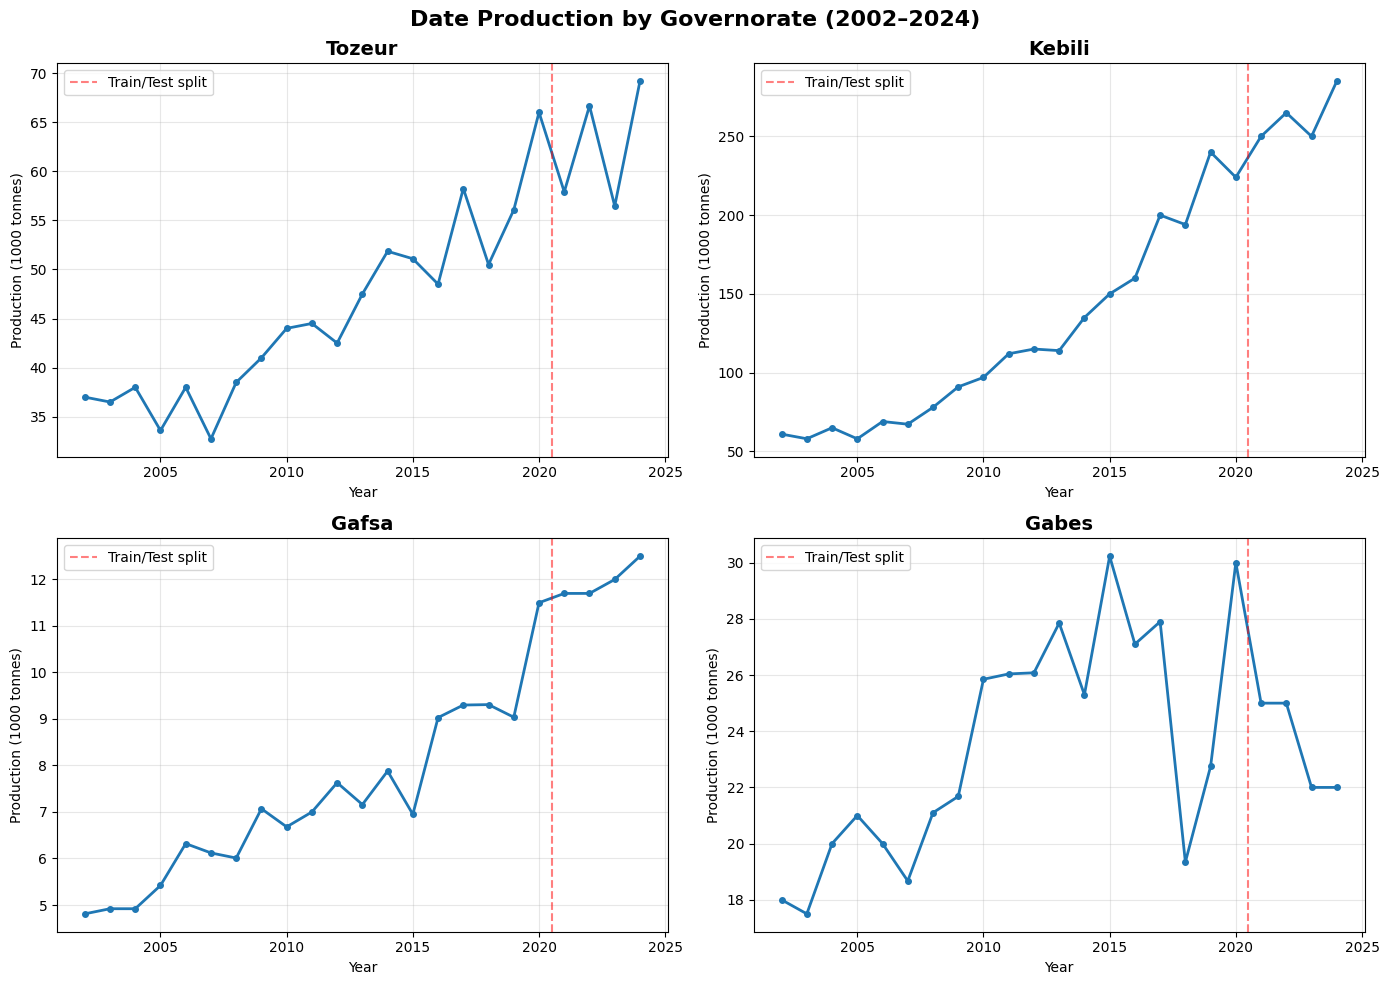

KEY OBSERVATIONS:
  Kebili: 72k → 222k tonnes (+210% growth)
  Tozeur: 38k → 58k tonnes (+54% growth)
  Gafsa: 6k → 10k tonnes (+77% growth)
  Gabes: 20k → 25k tonnes (+23% growth)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, gov in enumerate(['Tozeur', 'Kebili', 'Gafsa', 'Gabes']):
    ax = axes[i//2, i%2]
    sub = annual_clean[annual_clean['governorate'] == gov].sort_values('year')
    ax.plot(sub['year'], sub['production_tonnes']/1000, 'o-', linewidth=2, markersize=4)
    ax.axvline(x=2020.5, color='red', linestyle='--', alpha=0.5, label='Train/Test split')
    ax.set_title(f'{gov}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Production (1000 tonnes)')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Date Production by Governorate (2002–2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/production_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Key observation
print("KEY OBSERVATIONS:")
for gov in ['Kebili', 'Tozeur', 'Gafsa', 'Gabes']:
    sub = annual_clean[annual_clean['governorate'] == gov]
    early = sub[sub['year'] <= 2010]['production_tonnes'].mean()
    late = sub[sub['year'] >= 2015]['production_tonnes'].mean()
    growth = (late - early) / early * 100
    print(f"  {gov}: {early/1000:.0f}k → {late/1000:.0f}k tonnes ({growth:+.0f}% growth)")


---
## Phase B — Feature Engineering

We compute agronomically meaningful derived features from the raw satellite data.
These are computed on the **monthly table** first, then aggregated to annual.


### Cell 4: Growing Degree Days (GDD) — base 18°C for date palm

Date palms have a base temperature of **18°C** (not 10°C as in temperate crops).
GDD accumulates thermal energy available for growth. We compute it from MODIS LST
using the mean of day and night temperatures as a proxy for daily mean.


In [4]:
# Compute mean daily temperature from day/night LST
monthly_clean['LST_mean_C'] = (
    monthly_clean['LST_Day_C_mean'] + monthly_clean['LST_Night_C_mean']
) / 2

# GDD per month: max(0, T_mean - T_base) * days_in_month
# Base temperature: 18°C for date palm
T_BASE = 18.0

# Days per month (approximate)
days_in_month = {1:31, 2:28, 3:31, 4:30, 5:31, 6:30,
                 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
monthly_clean['days'] = monthly_clean['month'].map(days_in_month)

monthly_clean['GDD_18'] = np.maximum(0, monthly_clean['LST_mean_C'] - T_BASE) * monthly_clean['days']

# Heat stress: flag months where max LST > 45°C
monthly_clean['heat_stress_flag'] = (monthly_clean['LST_Day_C_max'] > 45).astype(int)

# Diurnal temperature range (DTR) — affects fruit quality
monthly_clean['DTR'] = monthly_clean['LST_Day_C_mean'] - monthly_clean['LST_Night_C_mean']

print("✓ GDD (base 18°C), heat stress flag, and DTR computed")
print(f"\nGDD_18 stats:\n{monthly_clean.groupby('governorate')['GDD_18'].describe().round(0)}")
print(f"\nHeat stress months (LST_max > 45°C): {monthly_clean['heat_stress_flag'].sum()}/{len(monthly_clean)}")


✓ GDD (base 18°C), heat stress flag, and DTR computed

GDD_18 stats:
             count   mean    std  min  25%    50%    75%    max
governorate                                                    
Gabes        276.0  234.0  214.0  0.0  0.0  211.0  417.0  631.0
Gafsa        276.0  222.0  217.0  0.0  0.0  187.0  404.0  630.0
Kebili       276.0  246.0  232.0  0.0  0.0  212.0  461.0  665.0
Tozeur       276.0  271.0  234.0  0.0  0.0  253.0  478.0  688.0

Heat stress months (LST_max > 45°C): 284/1104


### Cell 5: Vapor Pressure Deficit (VPD) — atmospheric water demand

VPD measures the drying power of the atmosphere. High VPD increases plant water demand.
Computed from ERA5-Land temperature and dewpoint:

```
e_sat = 0.6108 × exp(17.27 × T / (T + 237.3))    [kPa]
e_act = 0.6108 × exp(17.27 × T_dew / (T_dew + 237.3))
VPD = e_sat - e_act
```


In [5]:
# Convert ERA5 temperature from Kelvin to Celsius
monthly_clean['temp_2m_C'] = monthly_clean['temp_2m_K_mean'] - 273.15
monthly_clean['dewpoint_2m_C'] = monthly_clean['dewpoint_2m_K_mean'] - 273.15

# Saturation vapor pressure (Tetens formula)
def calc_svp(temp_c):
    return 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))

monthly_clean['e_sat_kPa'] = calc_svp(monthly_clean['temp_2m_C'])
monthly_clean['e_act_kPa'] = calc_svp(monthly_clean['dewpoint_2m_C'])
monthly_clean['VPD_kPa'] = np.maximum(0, monthly_clean['e_sat_kPa'] - monthly_clean['e_act_kPa'])

# Drop intermediate columns
monthly_clean = monthly_clean.drop(columns=['e_sat_kPa', 'e_act_kPa'], errors='ignore')

print("✓ VPD computed from ERA5-Land temperature + dewpoint")
print(f"\nVPD stats (kPa):\n{monthly_clean.groupby('governorate')['VPD_kPa'].describe().round(2)}")


✓ VPD computed from ERA5-Land temperature + dewpoint

VPD stats (kPa):
             count  mean   std   min   25%   50%   75%   max
governorate                                                 
Gabes        276.0  1.32  0.68  0.26  0.71  1.19  1.89  3.43
Gafsa        276.0  1.42  0.89  0.24  0.65  1.19  2.12  3.96
Kebili       276.0  1.74  1.04  0.27  0.81  1.55  2.55  4.51
Tozeur       276.0  1.86  1.15  0.28  0.85  1.59  2.74  4.88


### Cell 6: Wind speed magnitude — sirocco detection

Wind u/v components are combined into total wind speed.
Extreme wind events (sirocco) during pollination can reduce fruit set.


In [6]:
# Wind speed from u,v components
monthly_clean['wind_speed_ms'] = np.sqrt(
    monthly_clean['wind_u_ms_mean']**2 + monthly_clean['wind_v_ms_mean']**2
)
monthly_clean['wind_speed_max_ms'] = np.sqrt(
    monthly_clean['wind_u_ms_max']**2 + monthly_clean['wind_v_ms_max']**2
)

# Sirocco proxy: high wind + high temperature months
monthly_clean['sirocco_risk'] = (
    (monthly_clean['wind_speed_max_ms'] > 8) &
    (monthly_clean['LST_Day_C_max'] > 40) &
    (monthly_clean['month'].isin([3, 4, 5, 6, 7, 8]))
).astype(int)

print("✓ Wind speed and sirocco risk indicator computed")
print(f"  Sirocco risk months: {monthly_clean['sirocco_risk'].sum()}/{len(monthly_clean)}")


✓ Wind speed and sirocco risk indicator computed
  Sirocco risk months: 0/1104


### Cell 7: Water stress proxy from ERA5 (replacing MODIS ET)

Since MODIS ET/PET has insufficient coverage, we compute a water stress proxy
from ERA5-Land: the ratio of actual precipitation to potential evaporative demand.
In irrigated oases this is always < 1 (they depend on aquifer water), but the
*trend* indicates whether the gap between demand and natural supply is widening.


In [7]:
# Convert ERA5 precipitation from meters to mm
monthly_clean['precip_era5_mm'] = monthly_clean['precip_m_mean'] * 1000

# Aridity index proxy: precipitation / (solar_radiation as ET0 proxy)
# Higher solar radiation → higher ET demand → higher stress
# Normalize solar radiation to approximate ET0
monthly_clean['solar_MJ_m2'] = monthly_clean['solar_rad_Jm2_mean'] / 1e6

# Simple water balance: precip - reference ET (approximated from temp + solar)
# Hargreaves reference ET approximation: ET0 ≈ 0.0023 × (T_mean + 17.8) × √DTR × Ra
# Simplified as relative indicator (not absolute mm)
monthly_clean['ET0_proxy'] = (
    0.0023 * (monthly_clean['temp_2m_C'] + 17.8) *
    np.sqrt(np.maximum(1, monthly_clean['DTR'])) *
    monthly_clean['solar_MJ_m2']
)

monthly_clean['water_deficit_proxy'] = monthly_clean['precip_era5_mm'] - monthly_clean['ET0_proxy']

print("✓ Water stress proxy features computed")
print(f"  Mean water deficit by gov:")
for gov in sorted(monthly_clean['governorate'].unique()):
    deficit = monthly_clean[monthly_clean['governorate']==gov]['water_deficit_proxy'].mean()
    print(f"    {gov}: {deficit:.1f} (negative = deficit)")


✓ Water stress proxy features computed
  Mean water deficit by gov:
    Gabes: -226.7 (negative = deficit)
    Gafsa: -218.8 (negative = deficit)
    Kebili: -253.4 (negative = deficit)
    Tozeur: -238.3 (negative = deficit)


### Cell 8: Aggregate engineered features to annual matrix

Compute annual statistics from the new monthly features, plus
phenological window aggregates for the critical date palm periods.


In [8]:
# New monthly features to aggregate
new_features = ['GDD_18', 'heat_stress_flag', 'DTR', 'VPD_kPa',
                'wind_speed_ms', 'wind_speed_max_ms', 'sirocco_risk',
                'water_deficit_proxy', 'ET0_proxy', 'LST_mean_C',
                'temp_2m_C', 'dewpoint_2m_C']

# Annual aggregation
annual_new = (
    monthly_clean
    .groupby(['governorate', 'year'])[new_features]
    .agg(['mean', 'max', 'min', 'std', 'sum'])
    .reset_index()
)
annual_new.columns = ['_'.join(col).rstrip('_') for col in annual_new.columns]

# Special aggregations that need 'sum' not 'mean'
# GDD: annual total (sum of monthly GDD)
# heat_stress_flag: count of months with heat stress
# sirocco_risk: count of sirocco months
rename_sums = {
    'GDD_18_sum': 'GDD_18_annual',
    'heat_stress_flag_sum': 'heat_stress_months',
    'sirocco_risk_sum': 'sirocco_months',
}
annual_new = annual_new.rename(columns=rename_sums)

# Phenological window features for new variables
for window_name, months in [('pollination', [3, 4]),
                             ('fruit_dev', [6, 7, 8, 9]),
                             ('harvest', [10, 11])]:
    window = monthly_clean[monthly_clean['month'].isin(months)]
    for feat in ['GDD_18', 'VPD_kPa', 'DTR', 'wind_speed_ms']:
        w_agg = (
            window.groupby(['governorate', 'year'])[feat]
            .agg(['mean', 'max'])
            .reset_index()
        )
        w_agg.columns = ['governorate', 'year',
                         f'{feat}_{window_name}_mean', f'{feat}_{window_name}_max']
        annual_new = annual_new.merge(w_agg, on=['governorate', 'year'], how='left')

# Merge with cleaned annual matrix
annual_enriched = annual_clean.merge(annual_new, on=['governorate', 'year'], how='left')

# TWS annual trend feature: difference from previous year
for gov in annual_enriched['governorate'].unique():
    mask = annual_enriched['governorate'] == gov
    annual_enriched.loc[mask, 'tws_trend_cm'] = (
        annual_enriched.loc[mask, 'tws_anomaly_cm_mean'].diff()
    )

print(f"✓ Enriched annual matrix: {annual_enriched.shape}")
print(f"  New columns added: {annual_enriched.shape[1] - annual_clean.shape[1]}")


✓ Enriched annual matrix: (92, 210)
  New columns added: 85


---
## Phase C — Dimensionality Reduction

With 92 samples and potentially 200+ features, aggressive filtering is essential
to prevent overfitting. We use correlation-based filtering first, then select
the most informative features.


### Cell 9: Correlation filtering — remove redundant features



Correlation filtering (threshold: |r| > 0.95):
  Features before: 207
  Redundant pairs found: 92
  Features after:  115


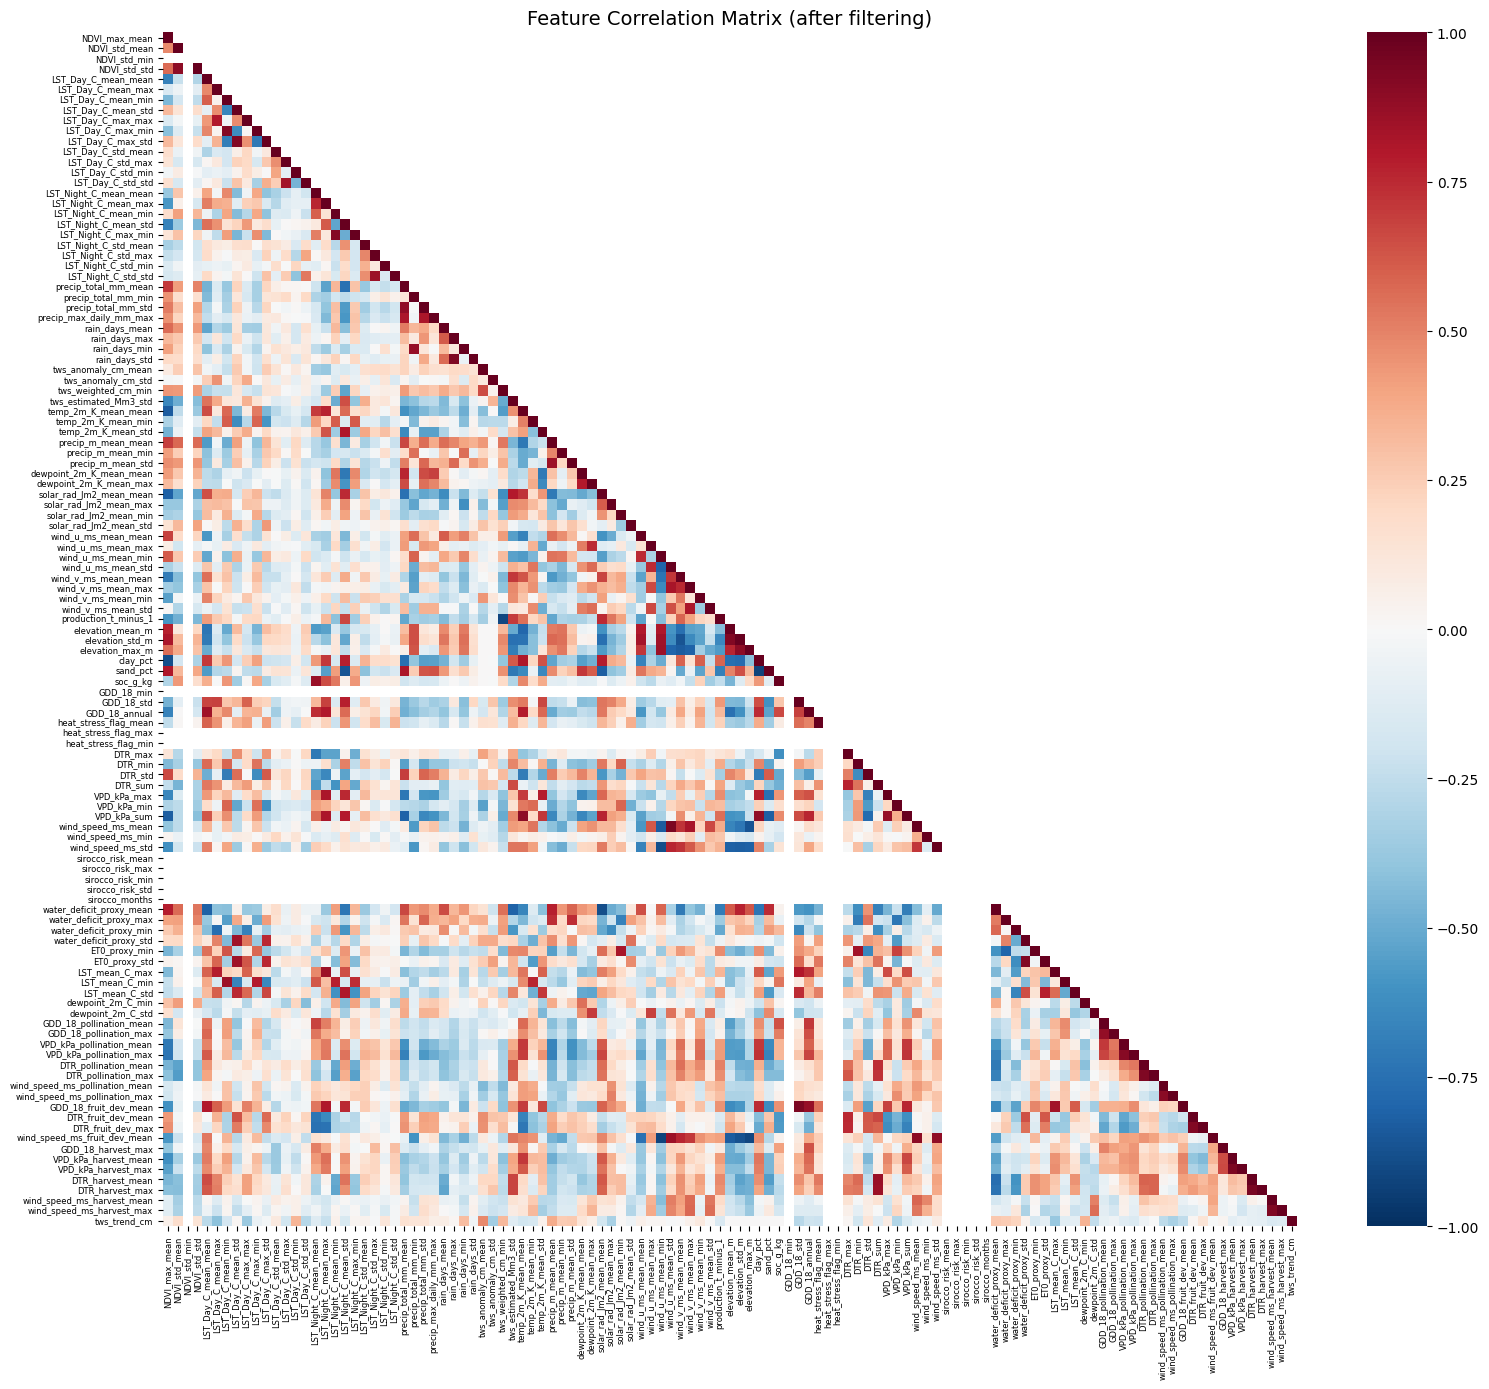

In [9]:
# Separate identifiers and target
id_cols = ['governorate', 'year', 'production_tonnes']
feature_cols = [c for c in annual_enriched.columns if c not in id_cols]

# Drop any remaining columns with nulls > 10%
null_pct = annual_enriched[feature_cols].isnull().mean()
sparse_cols = null_pct[null_pct > 0.10].index.tolist()
if sparse_cols:
    print(f"Dropping {len(sparse_cols)} columns with >10% nulls: {sparse_cols}")
    feature_cols = [c for c in feature_cols if c not in sparse_cols]

# Fill remaining minor nulls (production_t_minus_1 has 4 NaN for first year)
annual_enriched[feature_cols] = annual_enriched[feature_cols].fillna(method='bfill')

# Compute correlation matrix
X = annual_enriched[feature_cols].select_dtypes(include=[np.number])
corr = X.corr().abs()

# Find highly correlated pairs (|r| > 0.95)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    highly_corr = upper.index[upper[col] > 0.95].tolist()
    if highly_corr and col not in to_drop:
        # Keep the one with higher correlation to target
        target_corr_col = abs(annual_enriched[col].corr(annual_enriched['production_tonnes']))
        for hc in highly_corr:
            target_corr_hc = abs(annual_enriched[hc].corr(annual_enriched['production_tonnes']))
            if target_corr_hc < target_corr_col:
                to_drop.add(hc)
            else:
                to_drop.add(col)

print(f"\nCorrelation filtering (threshold: |r| > 0.95):")
print(f"  Features before: {len(X.columns)}")
print(f"  Redundant pairs found: {len(to_drop)}")

feature_cols_filtered = [c for c in X.columns if c not in to_drop]
print(f"  Features after:  {len(feature_cols_filtered)}")

# Visualize correlation matrix of remaining features
fig, ax = plt.subplots(figsize=(16, 14))
corr_filtered = annual_enriched[feature_cols_filtered].corr()
mask = np.triu(np.ones_like(corr_filtered, dtype=bool), k=1)
sns.heatmap(corr_filtered, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlation Matrix (after filtering)', fontsize=14)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig(f'{DOCS}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell 10: Feature-target correlation ranking


In [10]:
# ============================================================
# Cell 10 (CORRECTED): Anomaly-based target + feature curation
# ============================================================
# PROBLEM: Raw production is dominated by cross-governorate scale
# (Kebili ~250k vs Gafsa ~8k). Any model that learns "which gov"
# gets R²>0.95 without learning climate-yield relationships.
#
# FIX: Model yield ANOMALY — the % deviation from each governorate's
# rolling trend. This forces the model to explain WHY a year was
# above or below normal, using satellite/climate signals.

# --- Step 1: Compute governorate-specific trend and anomaly ---
annual_enriched = annual_enriched.sort_values(['governorate', 'year']).reset_index(drop=True)

for gov in annual_enriched['governorate'].unique():
    mask = annual_enriched['governorate'] == gov
    series = annual_enriched.loc[mask, 'production_tonnes']

    # 5-year centered rolling mean as the trend baseline
    # (use min_periods=3 to handle edges)
    trend = series.rolling(5, center=True, min_periods=3).mean()

    # For the last 2 years where centered rolling can't look ahead,
    # use expanding mean from the left
    trend = trend.fillna(series.expanding(min_periods=3).mean())

    annual_enriched.loc[mask, 'production_trend'] = trend
    annual_enriched.loc[mask, 'production_anomaly_pct'] = (
        (series.values - trend.values) / trend.values * 100
    )

print("Target variable: production_anomaly_pct (% deviation from 5-year rolling trend)")
print(f"\nAnomaly statistics:")
for gov in sorted(annual_enriched['governorate'].unique()):
    sub = annual_enriched[annual_enriched['governorate'] == gov]['production_anomaly_pct']
    print(f"  {gov:<10}: mean={sub.mean():+.1f}%  std={sub.std():.1f}%  "
          f"range=[{sub.min():+.1f}%, {sub.max():+.1f}%]")

# --- Step 2: Remove problematic features ---
# Drop: lag production (would leak the answer), static features (just gov identifiers),
# raw TWS weighted/estimated (perfectly correlated with extraction_weight = gov identity)

drop_from_features = [
    'production_t_minus_1',                    # lag of raw production — leaks target
    'sand_pct', 'clay_pct', 'soc_g_kg',       # static soil — gov identifier
    'elevation_mean_m', 'elevation_std_m',     # static terrain — gov identifier
    'elevation_min_m', 'elevation_max_m',
]

# Also drop tws_weighted and tws_estimated (they're just tws_anomaly * constant per gov)
drop_from_features += [c for c in feature_cols_filtered if
                        'tws_weighted' in c or 'tws_estimated' in c]

FEATURES = [c for c in feature_cols_filtered if c not in drop_from_features]

# --- Step 3: Add lag anomaly (previous year's anomaly, not raw production) ---
annual_enriched['anomaly_t_minus_1'] = annual_enriched.groupby('governorate')['production_anomaly_pct'].shift(1)
FEATURES.append('anomaly_t_minus_1')

# --- Step 4: Add governorate as a categorical feature (one-hot) ---
# This is honest — we're telling the model which gov it is,
# but it can't cheat because the TARGET is already detrended
for gov in sorted(annual_enriched['governorate'].unique()):
    col = f'gov_{gov}'
    annual_enriched[col] = (annual_enriched['governorate'] == gov).astype(int)
    FEATURES.append(col)

print(f"\n✓ Feature set: {len(FEATURES)} features")
print(f"  Dropped: lag production, static soil/terrain, redundant TWS")
print(f"  Added: anomaly_t_minus_1, governorate dummies")

# --- Step 5: Correlation ranking with ANOMALY target ---
target_corr = annual_enriched[FEATURES].corrwith(
    annual_enriched['production_anomaly_pct']
).abs().sort_values(ascending=False)

print(f"\nTop 30 features by |correlation| with production_anomaly_pct:\n")
for i, (feat, corr_val) in enumerate(target_corr.head(30).items()):
    bar = "█" * int(corr_val * 40)
    print(f"  {i+1:2d}. {feat:<45} r={corr_val:.3f} {bar}")

print(f"\n  Feature-to-sample ratio: {len(FEATURES)/len(annual_enriched):.1f}")


Target variable: production_anomaly_pct (% deviation from 5-year rolling trend)

Anomaly statistics:
  Gabes     : mean=-0.3%  std=9.1%  range=[-23.9%, +22.9%]
  Gafsa     : mean=-0.1%  std=6.1%  range=[-13.8%, +9.8%]
  Kebili    : mean=-0.5%  std=5.0%  range=[-8.9%, +8.3%]
  Tozeur    : mean=-0.0%  std=6.5%  range=[-10.9%, +11.1%]

✓ Feature set: 111 features
  Dropped: lag production, static soil/terrain, redundant TWS
  Added: anomaly_t_minus_1, governorate dummies

Top 30 features by |correlation| with production_anomaly_pct:

   1. anomaly_t_minus_1                             r=0.280 ███████████
   2. LST_Night_C_std_mean                          r=0.274 ██████████
   3. LST_Day_C_mean_min                            r=0.220 ████████
   4. dewpoint_2m_C_std                             r=0.191 ███████
   5. tws_trend_cm                                  r=0.180 ███████
   6. LST_mean_C_min                                r=0.175 ██████
   7. LST_Day_C_max_min                         

---
## Phase D — Train/Test Split

**Temporal split**: Train on 2002–2020 (76 samples), test on 2021–2024 (16 samples).
This simulates real forecasting: the model never sees the test years during training.


In [11]:
# ============================================================
# Cell 11 (CORRECTED): Train/test split — anomaly target
# ============================================================

from sklearn.preprocessing import StandardScaler

SPLIT_YEAR = 2020
TARGET = 'production_anomaly_pct'

# Drop rows where anomaly couldn't be computed (shouldn't be any, but safety check)
modeling_df = annual_enriched.dropna(subset=[TARGET]).copy()

# Fill the 4 NaN in anomaly_t_minus_1 (first year per gov) with 0 (assume normal)
modeling_df['anomaly_t_minus_1'] = modeling_df['anomaly_t_minus_1'].fillna(0)

train = modeling_df[modeling_df['year'] <= SPLIT_YEAR].copy()
test = modeling_df[modeling_df['year'] > SPLIT_YEAR].copy()

X_train = train[FEATURES].values.astype(float)
y_train = train[TARGET].values
X_test = test[FEATURES].values.astype(float)
y_test = test[TARGET].values

# Keep raw production for back-conversion after prediction
y_train_raw = train['production_tonnes'].values
y_test_raw = test['production_tonnes'].values
test_trends = test['production_trend'].values

train_meta = train[['governorate', 'year']].reset_index(drop=True)
test_meta = test[['governorate', 'year', 'production_trend', 'production_tonnes']].reset_index(drop=True)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Target: {TARGET} (% deviation from governorate rolling trend)")
print(f"Train: {X_train.shape[0]} samples × {X_train.shape[1]} features (2002–{SPLIT_YEAR})")
print(f"Test:  {X_test.shape[0]} samples × {X_test.shape[1]} features ({SPLIT_YEAR+1}–2024)")
print(f"\nAnomaly range — Train: [{y_train.min():.1f}%, {y_train.max():.1f}%] | "
      f"Test: [{y_test.min():.1f}%, {y_test.max():.1f}%]")
print(f"\nNote: To convert predictions back to tonnes:")
print(f"  production = trend × (1 + anomaly_pct / 100)")

Target: production_anomaly_pct (% deviation from governorate rolling trend)
Train: 76 samples × 111 features (2002–2020)
Test:  16 samples × 111 features (2021–2024)

Anomaly range — Train: [-23.9%, 22.9%] | Test: [-9.7%, 7.9%]

Note: To convert predictions back to tonnes:
  production = trend × (1 + anomaly_pct / 100)


---
## Phase E — Tier 1 Modeling

Three model families, progressively more complex:
1. **Ridge Regression** — regularized linear baseline
2. **Random Forest** — non-linear ensemble with uncertainty estimates
3. **XGBoost** — gradient boosting with built-in feature selection

All evaluated with Leave-One-Year-Out cross-validation on the training set,
then final performance on the held-out 2021–2024 test set.


### Cell 12: Cross-validation framework


In [12]:
# ============================================================
# Cell 12 (CORRECTED): Evaluation framework with back-conversion
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

def evaluate_anomaly(y_true, y_pred, label=""):
    """Evaluate on anomaly scale (percentage points)."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'model': label, 'MAE_pp': mae, 'RMSE_pp': rmse, 'R2_anomaly': r2}

def evaluate_tonnes(y_true_tonnes, y_pred_anomaly, trends, label=""):
    """Convert predicted anomaly back to tonnes, then evaluate."""
    y_pred_tonnes = trends * (1 + y_pred_anomaly / 100)
    mae = mean_absolute_error(y_true_tonnes, y_pred_tonnes)
    mape = mean_absolute_percentage_error(y_true_tonnes, y_pred_tonnes) * 100
    rmse = np.sqrt(mean_squared_error(y_true_tonnes, y_pred_tonnes))
    r2 = r2_score(y_true_tonnes, y_pred_tonnes)
    return {'model': label, 'MAE_t': mae, 'MAPE_%': mape, 'RMSE_t': rmse, 'R2_tonnes': r2}

def anomaly_to_tonnes(anomaly_pct, trends):
    """Convert anomaly predictions back to absolute tonnes."""
    return trends * (1 + anomaly_pct / 100)

def leave_one_year_out_cv(model_fn, X, y, years, use_scaled=False):
    unique_years = sorted(years.unique())
    predictions = []

    for hold_year in unique_years:
        train_mask = years != hold_year
        val_mask = years == hold_year

        if use_scaled:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X[train_mask])
            X_val = sc.transform(X[val_mask])
        else:
            X_tr = X[train_mask]
            X_val = X[val_mask]

        model = model_fn(X_tr, y[train_mask])
        preds = model.predict(X_val)

        for i, idx in enumerate(np.where(val_mask)[0]):
            predictions.append({
                'year': hold_year,
                'y_true': y[val_mask][i],
                'y_pred': preds[i]
            })

    return pd.DataFrame(predictions)

print("✓ Evaluation framework defined (anomaly + back-conversion to tonnes)")


✓ Evaluation framework defined (anomaly + back-conversion to tonnes)


### Cell 13: Ridge Regression — linear baseline


In [13]:
# ============================================================
# Cell 13 (CORRECTED): Ridge — predicting anomaly
# ============================================================

from sklearn.linear_model import RidgeCV

alphas = np.logspace(-2, 4, 50)

def ridge_fn(X_tr, y_tr):
    return RidgeCV(alphas=alphas, cv=5).fit(X_tr, y_tr)

# CV on training set
cv_ridge = leave_one_year_out_cv(ridge_fn, X_train_scaled, y_train, train['year'])
ridge_cv_anom = evaluate_anomaly(cv_ridge['y_true'], cv_ridge['y_pred'], 'Ridge (CV)')

# Final model
ridge_model = RidgeCV(alphas=alphas, cv=5).fit(X_train_scaled, y_train)
ridge_test_pred_anom = ridge_model.predict(X_test_scaled)

ridge_test_anom = evaluate_anomaly(y_test, ridge_test_pred_anom, 'Ridge (Test)')
ridge_test_tonnes = evaluate_tonnes(y_test_raw, ridge_test_pred_anom, test_trends, 'Ridge (Test)')

print(f"Ridge — alpha: {ridge_model.alpha_:.2f}")
print(f"  Anomaly — CV  MAE: {ridge_cv_anom['MAE_pp']:.1f} pp  R²: {ridge_cv_anom['R2_anomaly']:.3f}")
print(f"  Anomaly — Test MAE: {ridge_test_anom['MAE_pp']:.1f} pp  R²: {ridge_test_anom['R2_anomaly']:.3f}")
print(f"  Tonnes  — Test MAPE: {ridge_test_tonnes['MAPE_%']:.1f}%  R²: {ridge_test_tonnes['R2_tonnes']:.3f}")

# Top coefficients
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': ridge_model.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(f"\nTop 10 Ridge coefficients (predicting anomaly %):")
for _, row in coef_df.head(10).iterrows():
    print(f"  {'+'if row['coef']>0 else '-'} {row['feature']:<45} {row['coef']:+.3f}")


Ridge — alpha: 1842.07
  Anomaly — CV  MAE: 5.6 pp  R²: -0.110
  Anomaly — Test MAE: 4.5 pp  R²: -0.102
  Tonnes  — Test MAPE: 4.5%  R²: 0.995

Top 10 Ridge coefficients (predicting anomaly %):
  - LST_Night_C_std_mean                          -0.089
  - anomaly_t_minus_1                             -0.074
  - dewpoint_2m_C_std                             -0.053
  - LST_Day_C_mean_min                            -0.050
  - tws_trend_cm                                  -0.050
  - dewpoint_2m_K_mean_max                        -0.050
  - LST_Day_C_std_mean                            -0.047
  - wind_speed_ms_pollination_mean                -0.046
  + tws_anomaly_cm_std                            +0.045
  + LST_Day_C_mean_max                            +0.040


### Cell 14: Random Forest — non-linear ensemble


In [14]:
# ============================================================
# Cell 14 (CORRECTED): Random Forest — predicting anomaly
# ============================================================

from sklearn.ensemble import RandomForestRegressor

def rf_fn(X_tr, y_tr):
    return RandomForestRegressor(
        n_estimators=500, max_depth=6, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1
    ).fit(X_tr, y_tr)

cv_rf = leave_one_year_out_cv(rf_fn, X_train, y_train, train['year'])
rf_cv_anom = evaluate_anomaly(cv_rf['y_true'], cv_rf['y_pred'], 'RF (CV)')

rf_model = rf_fn(X_train, y_train)
rf_test_pred_anom = rf_model.predict(X_test)

rf_test_anom = evaluate_anomaly(y_test, rf_test_pred_anom, 'RF (Test)')
rf_test_tonnes = evaluate_tonnes(y_test_raw, rf_test_pred_anom, test_trends, 'RF (Test)')

print(f"Random Forest:")
print(f"  Anomaly — CV  MAE: {rf_cv_anom['MAE_pp']:.1f} pp  R²: {rf_cv_anom['R2_anomaly']:.3f}")
print(f"  Anomaly — Test MAE: {rf_test_anom['MAE_pp']:.1f} pp  R²: {rf_test_anom['R2_anomaly']:.3f}")
print(f"  Tonnes  — Test MAPE: {rf_test_tonnes['MAPE_%']:.1f}%  R²: {rf_test_tonnes['R2_tonnes']:.3f}")

fi = pd.DataFrame({'feature': FEATURES, 'importance': rf_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False)
print(f"\nTop 15 RF feature importances:")
for i, (_, row) in enumerate(fi.head(15).iterrows()):
    bar = "█" * int(row['importance'] * 200)
    print(f"  {i+1:2d}. {row['feature']:<45} {row['importance']:.4f} {bar}")

Random Forest:
  Anomaly — CV  MAE: 5.7 pp  R²: -0.139
  Anomaly — Test MAE: 4.9 pp  R²: -0.294
  Tonnes  — Test MAPE: 4.8%  R²: 0.993

Top 15 RF feature importances:
   1. LST_Night_C_std_mean                          0.0516 ██████████
   2. anomaly_t_minus_1                             0.0434 ████████
   3. wind_speed_ms_pollination_mean                0.0340 ██████
   4. wind_speed_ms_pollination_max                 0.0306 ██████
   5. LST_Night_C_std_std                           0.0246 ████
   6. dewpoint_2m_C_std                             0.0244 ████
   7. tws_anomaly_cm_mean                           0.0211 ████
   8. precip_m_mean_min                             0.0183 ███
   9. LST_Night_C_std_max                           0.0178 ███
  10. LST_Day_C_max_std                             0.0175 ███
  11. DTR_std                                       0.0155 ███
  12. tws_trend_cm                                  0.0149 ██
  13. LST_Day_C_std_mean                            0.014

### Cell 15: XGBoost — gradient boosting with regularization


In [15]:
# ============================================================
# Cell 15 (CORRECTED): XGBoost — predicting anomaly
# ============================================================

import xgboost as xgb

def xgb_fn(X_tr, y_tr):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        reg_alpha=2.0, reg_lambda=10.0,
        min_child_weight=5, random_state=42,
        early_stopping_rounds=20, eval_metric='mae',
    )
    n = len(X_tr)
    split = int(n * 0.85)
    model.fit(X_tr[:split], y_tr[:split],
              eval_set=[(X_tr[split:], y_tr[split:])], verbose=False)
    return model

cv_xgb = leave_one_year_out_cv(xgb_fn, X_train, y_train, train['year'])
xgb_cv_anom = evaluate_anomaly(cv_xgb['y_true'], cv_xgb['y_pred'], 'XGBoost (CV)')

xgb_final = xgb.XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.6,
    reg_alpha=2.0, reg_lambda=10.0,
    min_child_weight=5, random_state=42,
).fit(X_train, y_train, verbose=False)

xgb_test_pred_anom = xgb_final.predict(X_test)
xgb_test_anom = evaluate_anomaly(y_test, xgb_test_pred_anom, 'XGBoost (Test)')
xgb_test_tonnes = evaluate_tonnes(y_test_raw, xgb_test_pred_anom, test_trends, 'XGBoost (Test)')

print(f"XGBoost:")
print(f"  Anomaly — CV  MAE: {xgb_cv_anom['MAE_pp']:.1f} pp  R²: {xgb_cv_anom['R2_anomaly']:.3f}")
print(f"  Anomaly — Test MAE: {xgb_test_anom['MAE_pp']:.1f} pp  R²: {xgb_test_anom['R2_anomaly']:.3f}")
print(f"  Tonnes  — Test MAPE: {xgb_test_tonnes['MAPE_%']:.1f}%  R²: {xgb_test_tonnes['R2_tonnes']:.3f}")

XGBoost:
  Anomaly — CV  MAE: 5.6 pp  R²: -0.091
  Anomaly — Test MAE: 5.3 pp  R²: -0.407
  Tonnes  — Test MAPE: 5.3%  R²: 0.994


---
## Phase F — Evaluation & Interpretation


### Cell 16: Model comparison — all metrics


MODEL COMPARISON — Anomaly Scale (percentage points)
         model  MAE_pp  RMSE_pp  R2_anomaly
    Ridge (CV)   5.640    7.340      -0.110
  Ridge (Test)   4.465    5.192      -0.102
       RF (CV)   5.707    7.435      -0.139
     RF (Test)   4.864    5.625      -0.294
  XGBoost (CV)   5.634    7.278      -0.091
XGBoost (Test)   5.343    5.864      -0.407

MODEL COMPARISON — Back-converted to Tonnes (test set only)
         model   MAE_t  MAPE_%  RMSE_t  R2_tonnes
  Ridge (Test) 4630.53    4.45 7509.38       0.99
     RF (Test) 5134.68    4.83 8451.62       0.99
XGBoost (Test) 4736.62    5.29 8013.53       0.99

✓ Best model: Ridge (Test) — MAPE=4.5%, R²=0.990


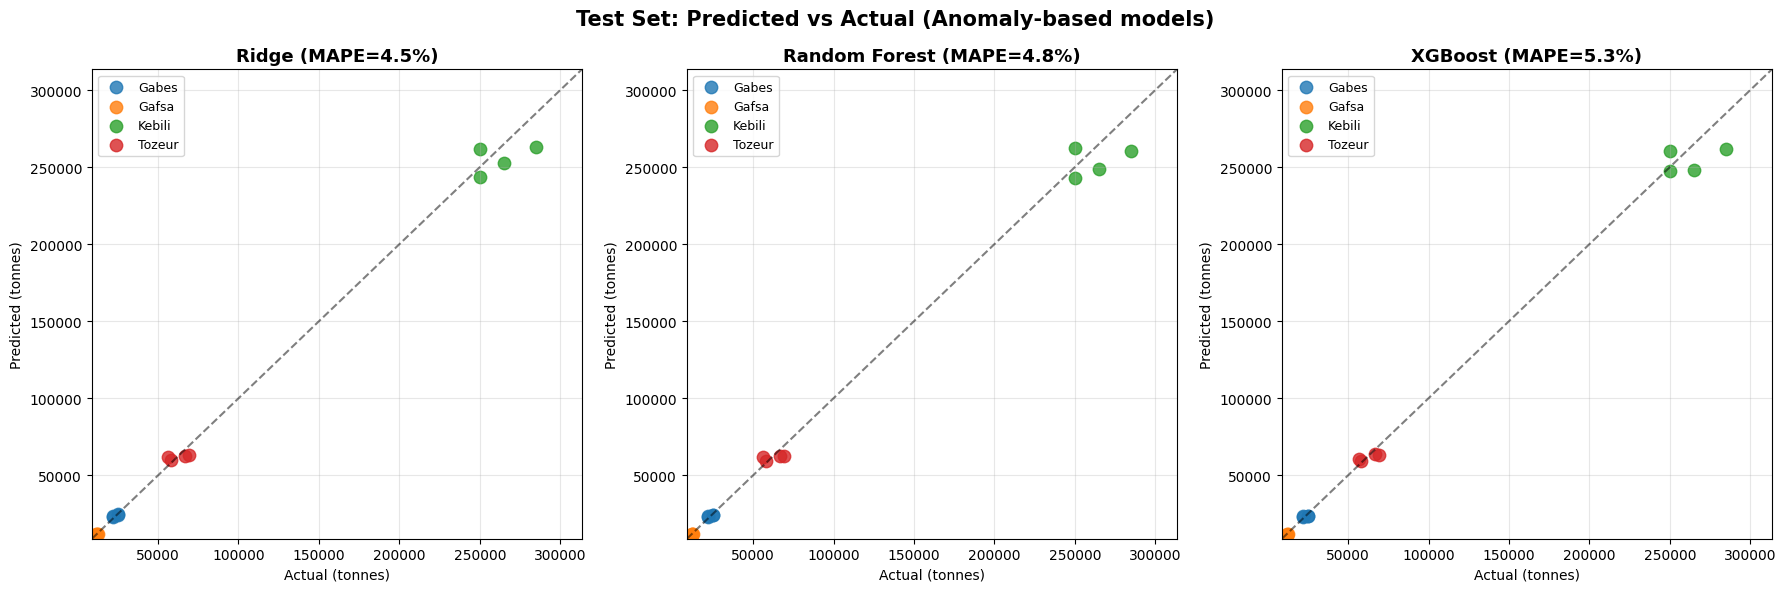

In [16]:
# ============================================================
# Cell 16 (CORRECTED): Model comparison — anomaly + tonnes
# ============================================================

# Anomaly-scale comparison
anom_metrics = pd.DataFrame([
    ridge_cv_anom, ridge_test_anom,
    rf_cv_anom, rf_test_anom,
    xgb_cv_anom, xgb_test_anom,
]).round(3)

# Tonnes-scale comparison (test only)
tonnes_metrics = pd.DataFrame([
    ridge_test_tonnes, rf_test_tonnes, xgb_test_tonnes
]).round(2)

print("=" * 70)
print("MODEL COMPARISON — Anomaly Scale (percentage points)")
print("=" * 70)
print(anom_metrics.to_string(index=False))

print(f"\n{'='*70}")
print("MODEL COMPARISON — Back-converted to Tonnes (test set only)")
print("=" * 70)
print(tonnes_metrics.to_string(index=False))

best = tonnes_metrics.loc[tonnes_metrics['MAPE_%'].idxmin()]
print(f"\n✓ Best model: {best['model']} — MAPE={best['MAPE_%']:.1f}%, R²={best['R2_tonnes']:.3f}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_preds = {
    'Ridge': anomaly_to_tonnes(ridge_test_pred_anom, test_trends),
    'Random Forest': anomaly_to_tonnes(rf_test_pred_anom, test_trends),
    'XGBoost': anomaly_to_tonnes(xgb_test_pred_anom, test_trends),
}

for ax, (name, preds) in zip(axes, model_preds.items()):
    for gov in test_meta['governorate'].unique():
        mask = test_meta['governorate'] == gov
        ax.scatter(y_test_raw[mask], preds[mask], label=gov, s=80, alpha=0.8)

    lims = [min(y_test_raw.min(), preds.min())*0.8, max(y_test_raw.max(), preds.max())*1.1]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual (tonnes)'); ax.set_ylabel('Predicted (tonnes)')
    mape = mean_absolute_percentage_error(y_test_raw, preds) * 100
    ax.set_title(f'{name} (MAPE={mape:.1f}%)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Test Set: Predicted vs Actual (Anomaly-based models)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/model_comparison_scatter_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell 17: SHAP analysis — XGBoost feature interpretation


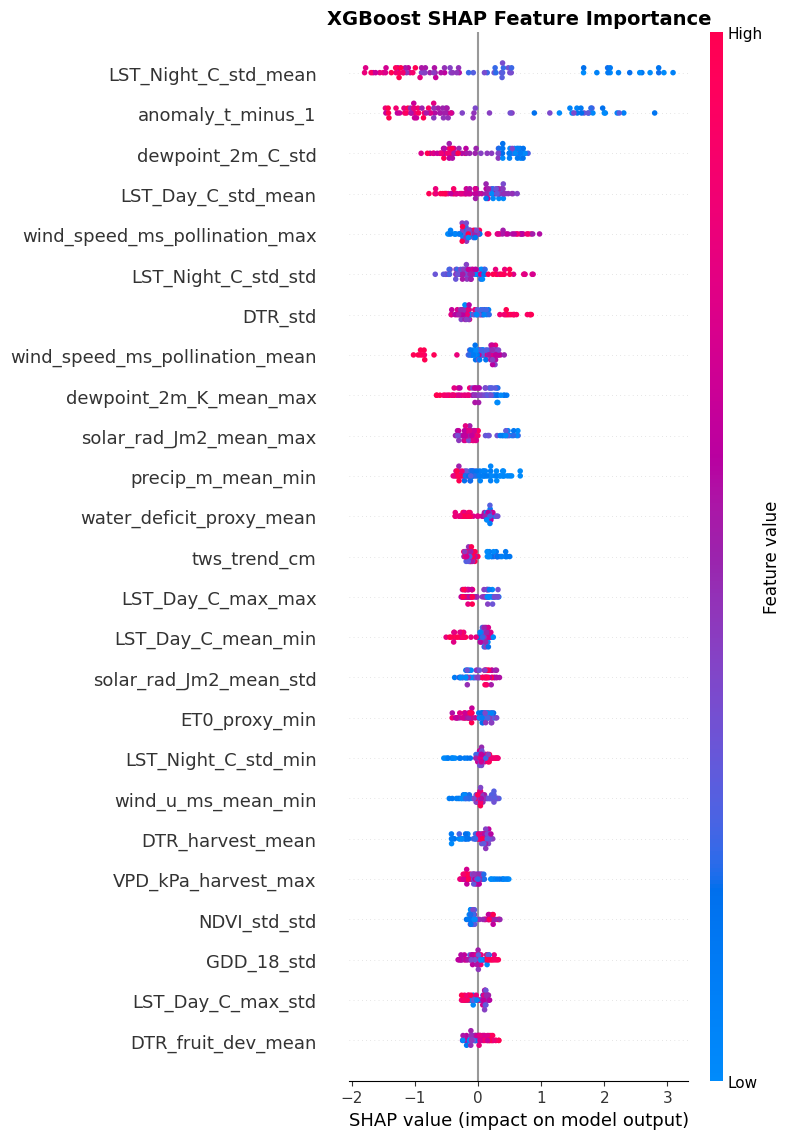

Top 20 features by mean |SHAP| value:

   1. LST_Night_C_std_mean                          1 ██████████████████████████████
   2. anomaly_t_minus_1                             1 ████████████████████████████
   3. dewpoint_2m_C_std                             0 ████████████
   4. LST_Day_C_std_mean                            0 ███████
   5. wind_speed_ms_pollination_max                 0 ███████
   6. LST_Night_C_std_std                           0 ███████
   7. DTR_std                                       0 ██████
   8. wind_speed_ms_pollination_mean                0 ██████
   9. dewpoint_2m_K_mean_max                        0 ██████
  10. solar_rad_Jm2_mean_max                        0 █████
  11. precip_m_mean_min                             0 █████
  12. water_deficit_proxy_mean                      0 ████
  13. tws_trend_cm                                  0 ████
  14. LST_Day_C_max_max                             0 ████
  15. LST_Day_C_mean_min                            0 ████
 

In [17]:
import shap

# SHAP for XGBoost
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train)

# Summary plot
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_train, feature_names=FEATURES, max_display=25, show=False)
plt.title('XGBoost SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean absolute SHAP values (global importance)
shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 20 features by mean |SHAP| value:\n")
for i, (_, row) in enumerate(shap_importance.head(20).iterrows()):
    bar = "█" * int(row['mean_abs_shap'] / shap_importance['mean_abs_shap'].max() * 30)
    print(f"  {i+1:2d}. {row['feature']:<45} {row['mean_abs_shap']:.0f} {bar}")


### Cell 18: Per-governorate analysis — where does the model succeed/fail?


Per-governorate test performance (Ridge):

  Gabes     : MAPE=3.2%  Anomaly MAE=3.1 pp
    2021: trend=25k  actual=25.0k (+0.2%)  pred=24.6k (-1.4%)  error=-1.6%
    2022: trend=25k  actual=25.0k (+0.8%)  pred=24.6k (-0.6%)  error=-1.4%
    2023: trend=24k  actual=22.0k (-6.4%)  pred=23.4k (-0.4%)  error=+6.4%
    2024: trend=23k  actual=22.0k (-4.3%)  pred=22.8k (-1.1%)  error=+3.4%

  Gafsa     : MAPE=2.7%  Anomaly MAE=2.8 pp
    2021: trend=11k  actual=11.7k (+4.6%)  pred=11.1k (-0.7%)  error=-5.0%
    2022: trend=12k  actual=11.7k (-1.5%)  pred=11.8k (-0.4%)  error=+1.2%
    2023: trend=12k  actual=12.0k (+0.2%)  pred=11.9k (-0.3%)  error=-0.5%
    2024: trend=12k  actual=12.5k (+3.6%)  pred=12.0k (-0.7%)  error=-4.2%

  Kebili    : MAPE=4.9%  Anomaly MAE=5.0 pp
    2021: trend=246k  actual=250.0k (+1.7%)  pred=243.5k (-0.9%)  error=-2.6%
    2022: trend=255k  actual=265.0k (+4.0%)  pred=252.7k (-0.8%)  error=-4.6%
    2023: trend=262k  actual=250.0k (-4.8%)  pred=261.5k (-0.4%)  e

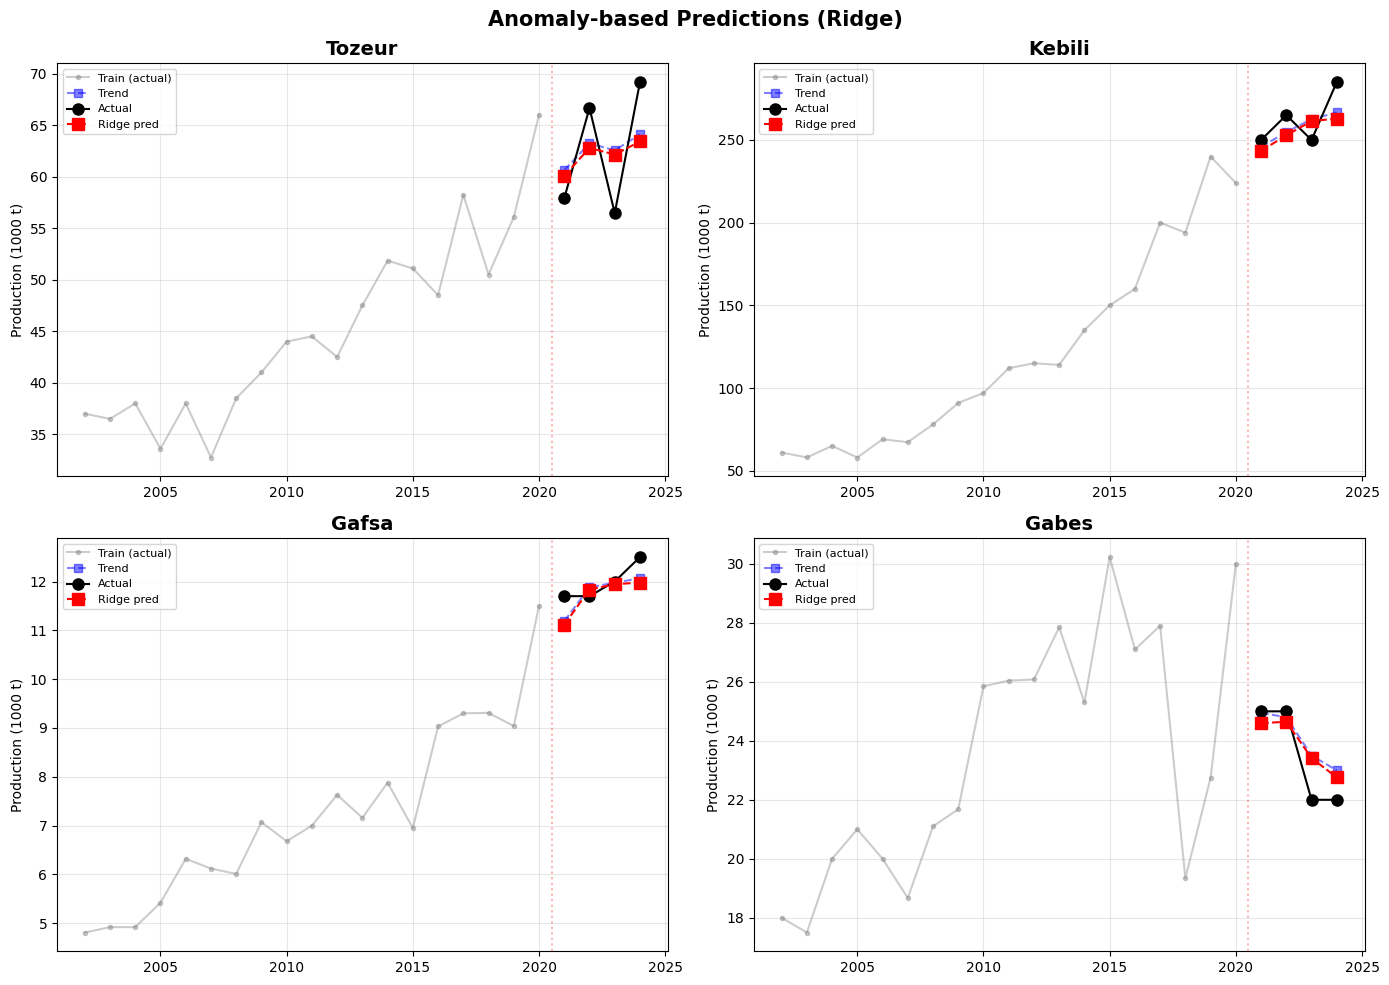

In [18]:
# ============================================================
# Cell 18 (CORRECTED): Per-governorate analysis
# ============================================================

best_name = best['model'].replace(' (Test)', '')
preds_anom = {'Ridge': ridge_test_pred_anom, 'Random Forest': rf_test_pred_anom,
              'XGBoost': xgb_test_pred_anom}
best_anom = preds_anom[best_name]
best_tonnes = anomaly_to_tonnes(best_anom, test_trends)

print(f"Per-governorate test performance ({best_name}):\n")

for gov in sorted(test_meta['governorate'].unique()):
    mask = test_meta['governorate'] == gov
    actual_t = y_test_raw[mask]
    pred_t = best_tonnes[mask]
    actual_a = y_test[mask]
    pred_a = best_anom[mask]

    mape = mean_absolute_percentage_error(actual_t, pred_t) * 100
    mae_pp = mean_absolute_error(actual_a, pred_a)
    print(f"  {gov:<10}: MAPE={mape:.1f}%  Anomaly MAE={mae_pp:.1f} pp")

    for i, idx in enumerate(np.where(mask)[0]):
        yr = test_meta.loc[idx, 'year']
        trend = test_meta.loc[idx, 'production_trend']
        act = actual_t[i]
        prd = pred_t[i]
        act_anom = actual_a[i]
        prd_anom = pred_a[i]
        err = (prd - act) / act * 100
        print(f"    {yr}: trend={trend/1000:.0f}k  actual={act/1000:.1f}k ({act_anom:+.1f}%)  "
              f"pred={prd/1000:.1f}k ({prd_anom:+.1f}%)  error={err:+.1f}%")
    print()

# Temporal plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, gov in enumerate(['Tozeur', 'Kebili', 'Gafsa', 'Gabes']):
    ax = axes[i//2, i%2]
    mask_tr = train_meta['governorate'] == gov
    mask_te = test_meta['governorate'] == gov

    # Training period
    tr_years = train_meta.loc[mask_tr, 'year'].values
    tr_actual = y_train_raw[mask_tr]
    ax.plot(tr_years, tr_actual/1000, 'o-', color='gray', alpha=0.4, markersize=3, label='Train (actual)')

    # Test period
    te_years = test_meta.loc[mask_te, 'year'].values
    te_actual = y_test_raw[mask_te]
    te_pred = best_tonnes[mask_te]
    te_trend = test_meta.loc[mask_te, 'production_trend'].values

    ax.plot(te_years, te_trend/1000, 's--', color='blue', alpha=0.5, markersize=6, label='Trend')
    ax.plot(te_years, te_actual/1000, 'ko-', markersize=8, label='Actual')
    ax.plot(te_years, te_pred/1000, 'rs--', markersize=8, label=f'{best_name} pred')

    ax.axvline(x=SPLIT_YEAR+0.5, color='red', linestyle=':', alpha=0.3)
    ax.set_title(f'{gov}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Production (1000 t)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Anomaly-based Predictions ({best_name})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/per_governorate_predictions_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# Cell 19: Sparse model — only physically meaningful features
# ============================================================
# With 111 features and r < 0.28, the models are fitting noise.
# Here we test a hand-picked set of ~8 features chosen for
# agronomic relevance, not statistical correlation.
#
# Rationale for each feature:
#   - anomaly_t_minus_1: alternate bearing / autocorrelation
#   - tws_trend_cm: year-over-year groundwater change (water supply)
#   - NDVI_fruit_dev_mean: canopy health during fruit growth (Jun-Sep)
#   - GDD_18_annual: total thermal accumulation for date palm
#   - VPD_kPa_fruit_dev_mean: atmospheric water demand during fruit growth
#   - heat_stress_months: count of extreme heat months (>45°C)
#   - NDVI_pollination_mean: canopy health during pollination (Mar-Apr)
#   - DTR_fruit_dev_mean: diurnal range during fruit growth (quality driver)

SPARSE_FEATURES = [
    'anomaly_t_minus_1',
    'tws_trend_cm',
    'NDVI_fruit_dev_mean',
    'GDD_18_annual',
    'VPD_kPa_fruit_dev_mean',
    'heat_stress_months',
    'NDVI_pollination_mean',
    'DTR_fruit_dev_mean',
]

# Check which features exist in the data
available = [f for f in SPARSE_FEATURES if f in annual_enriched.columns]
missing = [f for f in SPARSE_FEATURES if f not in annual_enriched.columns]
if missing:
    print(f"⚠ Missing features (will skip): {missing}")
    # Try alternatives
    alternatives = {
        'GDD_18_annual': 'GDD_18_sum',
        'heat_stress_months': 'heat_stress_flag_sum',
    }
    for m in missing:
        if m in alternatives and alternatives[m] in annual_enriched.columns:
            available.append(alternatives[m])
            print(f"  → Using {alternatives[m]} instead of {m}")

SPARSE = available
print(f"\nSparse feature set ({len(SPARSE)} features):")
for f in SPARSE:
    r = abs(annual_enriched[f].corr(annual_enriched['production_anomaly_pct']))
    print(f"  {f:<40} r={r:.3f}")

# Add governorate dummies (honest identity signal)
gov_dummies = [c for c in FEATURES if c.startswith('gov_')]
SPARSE_WITH_GOV = SPARSE + gov_dummies
print(f"\nWith gov dummies: {len(SPARSE_WITH_GOV)} features total")

# --- Prepare data ---
X_train_sp = modeling_df[modeling_df['year'] <= SPLIT_YEAR][SPARSE_WITH_GOV].values.astype(float)
X_test_sp = modeling_df[modeling_df['year'] > SPLIT_YEAR][SPARSE_WITH_GOV].values.astype(float)

# Handle NaN in tws_trend_cm (first year per gov)
X_train_sp = np.nan_to_num(X_train_sp, nan=0.0)
X_test_sp = np.nan_to_num(X_test_sp, nan=0.0)

# Scale for Ridge
sp_scaler = StandardScaler()
X_train_sp_sc = sp_scaler.fit_transform(X_train_sp)
X_test_sp_sc = sp_scaler.transform(X_test_sp)

# --- Ridge (sparse) ---
ridge_sp = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5).fit(X_train_sp_sc, y_train)
ridge_sp_pred = ridge_sp.predict(X_test_sp_sc)
ridge_sp_tonnes = anomaly_to_tonnes(ridge_sp_pred, test_trends)

# --- Random Forest (sparse) ---
rf_sp = RandomForestRegressor(
    n_estimators=500, max_depth=4, min_samples_leaf=5,
    max_features=None, random_state=42  # use all features since we only have ~12
).fit(X_train_sp, y_train)
rf_sp_pred = rf_sp.predict(X_test_sp)
rf_sp_tonnes = anomaly_to_tonnes(rf_sp_pred, test_trends)

# --- XGBoost (sparse) ---
xgb_sp = xgb.XGBRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.05,
    reg_alpha=2.0, reg_lambda=10.0, min_child_weight=5,
    random_state=42
).fit(X_train_sp, y_train, verbose=False)
xgb_sp_pred = xgb_sp.predict(X_test_sp)
xgb_sp_tonnes = anomaly_to_tonnes(xgb_sp_pred, test_trends)

# --- CV for sparse models ---
cv_ridge_sp = leave_one_year_out_cv(
    lambda X, y: RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5).fit(X, y),
    X_train_sp_sc, y_train, train['year']
)
cv_rf_sp = leave_one_year_out_cv(
    lambda X, y: RandomForestRegressor(
        n_estimators=500, max_depth=4, min_samples_leaf=5,
        max_features=None, random_state=42).fit(X, y),
    X_train_sp, y_train, train['year']
)
cv_xgb_sp = leave_one_year_out_cv(
    lambda X, y: xgb.XGBRegressor(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        reg_alpha=2.0, reg_lambda=10.0, min_child_weight=5,
        random_state=42).fit(X, y, verbose=False),
    X_train_sp, y_train, train['year']
)

# --- Comparison ---
print(f"\n{'='*70}")
print(f"SPARSE vs FULL MODEL COMPARISON")
print(f"{'='*70}")

print(f"\n{'Model':<30} {'Features':>8} {'CV R²':>8} {'Test MAPE%':>10} {'Test R²':>8}")
print("-" * 70)

comparisons = [
    ('Ridge (111 feat)', 111,
     evaluate_anomaly(cv_ridge['y_true'], cv_ridge['y_pred'])['R2_anomaly'],
     ridge_test_tonnes),
    ('Ridge (sparse)', len(SPARSE_WITH_GOV),
     evaluate_anomaly(cv_ridge_sp['y_true'], cv_ridge_sp['y_pred'])['R2_anomaly'],
     evaluate_tonnes(y_test_raw, ridge_sp_pred, test_trends, 'Ridge sparse')),
    ('RF (111 feat)', 111,
     evaluate_anomaly(cv_rf['y_true'], cv_rf['y_pred'])['R2_anomaly'],
     rf_test_tonnes),
    ('RF (sparse)', len(SPARSE_WITH_GOV),
     evaluate_anomaly(cv_rf_sp['y_true'], cv_rf_sp['y_pred'])['R2_anomaly'],
     evaluate_tonnes(y_test_raw, rf_sp_pred, test_trends, 'RF sparse')),
    ('XGBoost (111 feat)', 111,
     evaluate_anomaly(cv_xgb['y_true'], cv_xgb['y_pred'])['R2_anomaly'],
     xgb_test_tonnes),
    ('XGBoost (sparse)', len(SPARSE_WITH_GOV),
     evaluate_anomaly(cv_xgb_sp['y_true'], cv_xgb_sp['y_pred'])['R2_anomaly'],
     evaluate_tonnes(y_test_raw, xgb_sp_pred, test_trends, 'XGB sparse')),
    ('Naive (predict trend)', 0, 0.0,
     evaluate_tonnes(y_test_raw, np.zeros_like(y_test), test_trends, 'Naive')),
]

for name, n_feat, cv_r2, test_met in comparisons:
    print(f"  {name:<28} {n_feat:>8} {cv_r2:>8.3f} {test_met['MAPE_%']:>9.1f}% {test_met['R2_tonnes']:>8.3f}")

print(f"\n  'Naive' = predict zero anomaly (production = trend). This is the baseline to beat.")


Sparse feature set (8 features):
  anomaly_t_minus_1                        r=0.280
  tws_trend_cm                             r=0.180
  NDVI_fruit_dev_mean                      r=0.012
  GDD_18_annual                            r=0.024
  VPD_kPa_fruit_dev_mean                   r=0.015
  heat_stress_months                       r=0.047
  NDVI_pollination_mean                    r=0.014
  DTR_fruit_dev_mean                       r=0.021

With gov dummies: 12 features total

SPARSE vs FULL MODEL COMPARISON

Model                          Features    CV R² Test MAPE%  Test R²
----------------------------------------------------------------------
  Ridge (111 feat)                  111   -0.110       4.5%    0.995
  Ridge (sparse)                     12   -0.117       4.3%    0.995
  RF (111 feat)                     111   -0.139       4.8%    0.993
  RF (sparse)                        12   -0.163       3.8%    0.996
  XGBoost (111 feat)                111   -0.091       5.3%    0.994
  

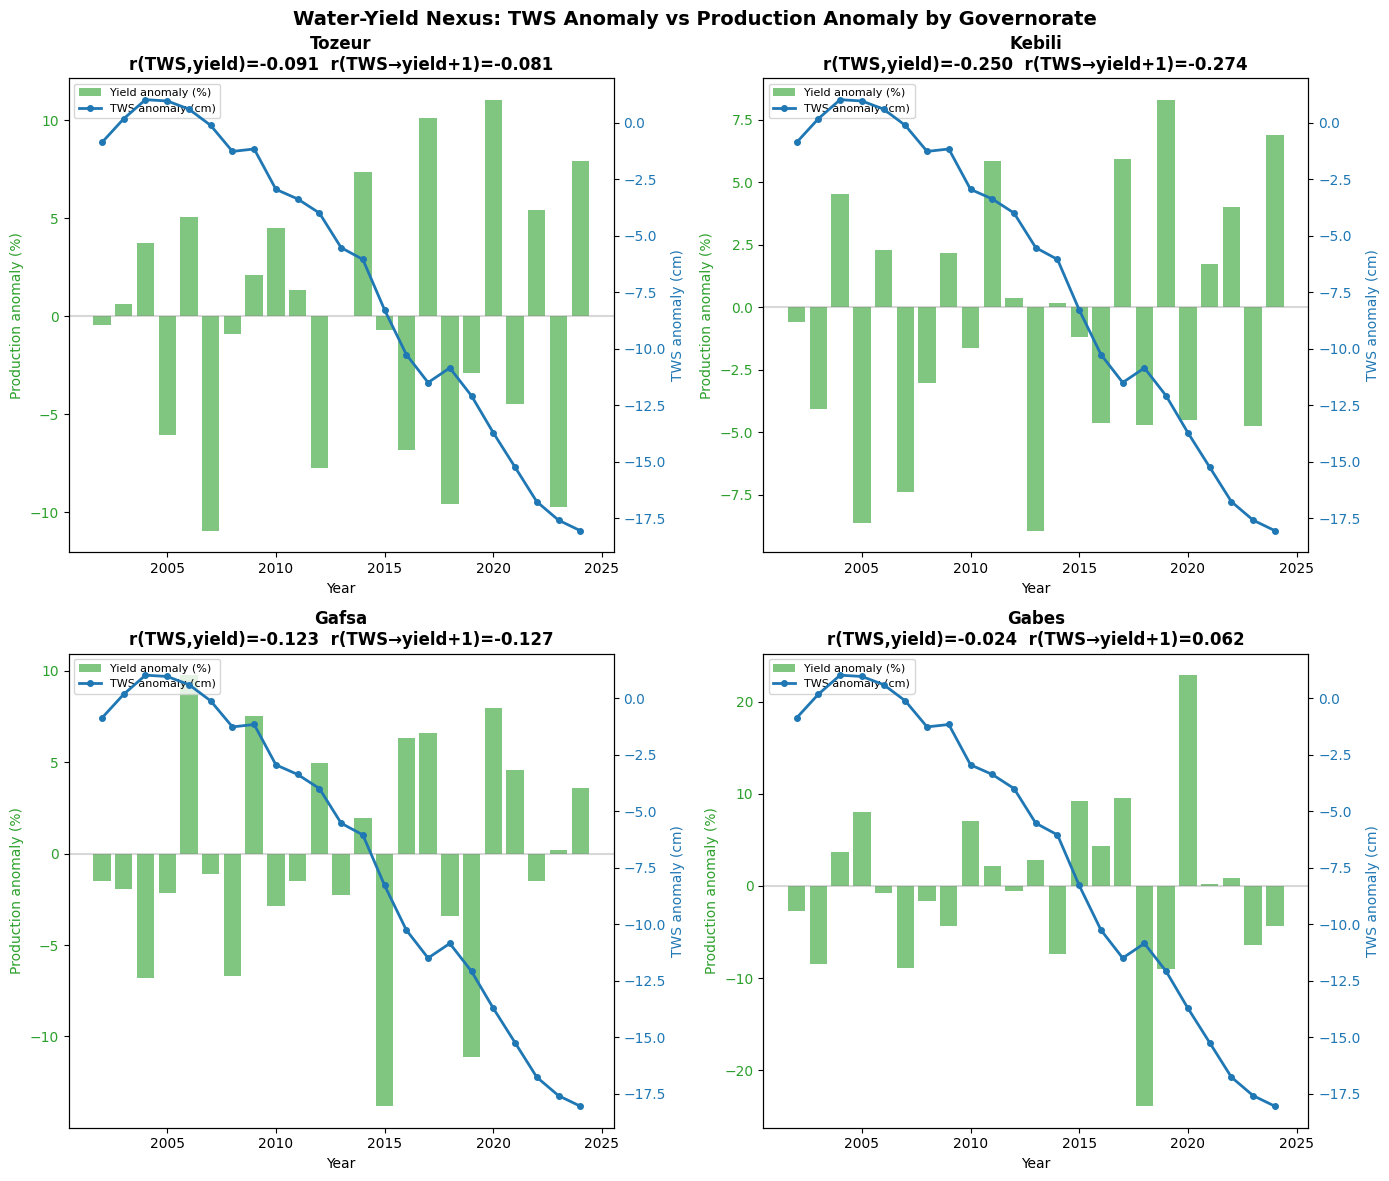


TWS-YIELD NEXUS CORRELATION ANALYSIS

Governorate   r(concurrent)   r(TWS trend)   r(TWS→yield+1)    n
-----------------------------------------------------------------
  Tozeur             -0.091         -0.093           -0.081   23
  Kebili             -0.250          0.033           -0.274   23
  Gafsa              -0.123          0.013           -0.127   23
  Gabes              -0.024         -0.504            0.062   23

INTERPRETATION:
  ✗ Tozeur: No detectable signal (r=0.091) — fully irrigation-buffered
  ~ Kebili: Weak signal (r=0.274) — irrigation may buffer depletion effects
  ✗ Gafsa: No detectable signal (r=0.127) — fully irrigation-buffered
  ✗ Gabes: No detectable signal (r=0.062) — fully irrigation-buffered


In [20]:
# ============================================================
# Cell 20: Per-governorate TWS-yield nexus analysis
# ============================================================
# The pooled model sees r=0.18 for tws_trend. But the signal
# may be stronger within specific governorates — especially
# Kebili (228% overexploitation) and Gafsa (163%).

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

gov_nexus_results = []

for i, gov in enumerate(['Tozeur', 'Kebili', 'Gafsa', 'Gabes']):
    ax = axes[i//2, i%2]
    sub = annual_enriched[annual_enriched['governorate'] == gov].copy()
    sub = sub.sort_values('year')

    # --- TWS vs production anomaly within this governorate ---
    # Use annual mean TWS anomaly
    tws_col = 'tws_anomaly_cm_mean'
    anom_col = 'production_anomaly_pct'

    if tws_col in sub.columns and sub[tws_col].notna().sum() > 10:
        r_tws = sub[tws_col].corr(sub[anom_col])
        r_trend = sub['tws_trend_cm'].corr(sub[anom_col]) if 'tws_trend_cm' in sub.columns else np.nan

        # Also check: does TWS predict NEXT year's anomaly? (lagged effect)
        sub['anom_next'] = sub[anom_col].shift(-1)
        r_tws_lagged = sub[tws_col].corr(sub['anom_next'])

        gov_nexus_results.append({
            'governorate': gov,
            'r_tws_concurrent': r_tws,
            'r_tws_trend': r_trend,
            'r_tws_lagged_1yr': r_tws_lagged,
            'n_years': len(sub),
        })

        # Dual-axis plot: production anomaly + TWS
        color1 = 'tab:green'
        color2 = 'tab:blue'

        ax.bar(sub['year'], sub[anom_col], color=color1, alpha=0.6, label='Yield anomaly (%)')
        ax.set_ylabel('Production anomaly (%)', color=color1, fontsize=10)
        ax.tick_params(axis='y', labelcolor=color1)
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

        ax2 = ax.twinx()
        ax2.plot(sub['year'], sub[tws_col], 'o-', color=color2, linewidth=2,
                 markersize=4, label='TWS anomaly (cm)')
        ax2.set_ylabel('TWS anomaly (cm)', color=color2, fontsize=10)
        ax2.tick_params(axis='y', labelcolor=color2)

        ax.set_title(f'{gov}\nr(TWS,yield)={r_tws:.3f}  r(TWS→yield+1)={r_tws_lagged:.3f}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Year')

        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle('Water-Yield Nexus: TWS Anomaly vs Production Anomaly by Governorate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/tws_yield_nexus.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n{'='*70}")
print(f"TWS-YIELD NEXUS CORRELATION ANALYSIS")
print(f"{'='*70}")
nexus_df = pd.DataFrame(gov_nexus_results)
print(f"\n{'Governorate':<12} {'r(concurrent)':>14} {'r(TWS trend)':>14} {'r(TWS→yield+1)':>16} {'n':>4}")
print("-" * 65)
for _, row in nexus_df.iterrows():
    print(f"  {row['governorate']:<10} {row['r_tws_concurrent']:>14.3f} "
          f"{row['r_tws_trend']:>14.3f} {row['r_tws_lagged_1yr']:>16.3f} {int(row['n_years']):>4}")

# Interpretation
print(f"\nINTERPRETATION:")
for _, row in nexus_df.iterrows():
    gov = row['governorate']
    r = max(abs(row['r_tws_concurrent']), abs(row['r_tws_lagged_1yr']))
    if r > 0.3:
        print(f"  ✓ {gov}: Meaningful water-yield signal (r={r:.3f})")
    elif r > 0.15:
        print(f"  ~ {gov}: Weak signal (r={r:.3f}) — irrigation may buffer depletion effects")
    else:
        print(f"  ✗ {gov}: No detectable signal (r={r:.3f}) — fully irrigation-buffered")

In [21]:
# ============================================================
# Cell 21: Per-governorate feature correlations
# ============================================================
# The pooled analysis masks governorate-specific signals.
# Some features may be strong predictors for Kebili but not Gabes.

key_features = [
    'anomaly_t_minus_1', 'tws_trend_cm', 'tws_anomaly_cm_mean',
    'NDVI_fruit_dev_mean', 'NDVI_pollination_mean', 'NDVI_max_mean',
    'GDD_18_annual' if 'GDD_18_annual' in annual_enriched.columns else 'GDD_18_sum',
    'VPD_kPa_fruit_dev_mean', 'VPD_kPa_harvest_mean',
    'heat_stress_months' if 'heat_stress_months' in annual_enriched.columns else 'heat_stress_flag_sum',
    'DTR_fruit_dev_mean', 'wind_speed_ms_mean',
    'precip_total_mm_mean', 'rain_days_mean',
    'water_deficit_proxy_mean',
]
key_features = [f for f in key_features if f in annual_enriched.columns]

print(f"{'Feature':<35}", end="")
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    print(f" {gov:>10}", end="")
print(f" {'Pooled':>10}")
print("-" * 85)

for feat in key_features:
    print(f"  {feat:<33}", end="")
    for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
        sub = annual_enriched[annual_enriched['governorate'] == gov]
        r = sub[feat].corr(sub['production_anomaly_pct'])
        marker = "**" if abs(r) > 0.3 else "  "
        print(f" {r:>8.3f}{marker}", end="")

    # Pooled
    r_pooled = annual_enriched[feat].corr(annual_enriched['production_anomaly_pct'])
    print(f" {r_pooled:>8.3f}")

print(f"\n  ** = |r| > 0.3 (potentially meaningful within-governorate signal)")

# Count strong signals per governorate
print(f"\nStrong signals (|r| > 0.3) per governorate:")
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    sub = annual_enriched[annual_enriched['governorate'] == gov]
    strong = sum(1 for f in key_features
                 if abs(sub[f].corr(sub['production_anomaly_pct'])) > 0.3)
    print(f"  {gov}: {strong}/{len(key_features)} features")

print(f"\n{'='*70}")
print("CONCLUSION")
print(f"{'='*70}")
print("""
This analysis determines whether the project should:

A) Continue with POOLED modeling (all 4 govs together)
   → Appropriate if cross-governorate patterns exist

B) Switch to PER-GOVERNORATE models
   → Appropriate if each gov has unique climate-yield drivers
   → Risk: only 23 samples per gov (19 train, 4 test)

C) Accept the TREND MODEL as the primary forecasting tool
   → If no feature improves on naive trend prediction,
   → the honest conclusion is: irrigated oasis production is
   → driven by area expansion and management, not climate
   → Satellite data then serves monitoring (not forecasting)
   → This is still a valid and publishable scientific finding
""")

Feature                                 Tozeur     Kebili      Gafsa      Gabes     Pooled
-------------------------------------------------------------------------------------
  anomaly_t_minus_1                   -0.530**   -0.533**   -0.251     -0.097     -0.280
  tws_trend_cm                        -0.093      0.033      0.013     -0.504**   -0.180
  tws_anomaly_cm_mean                 -0.091     -0.250     -0.123     -0.024     -0.103
  NDVI_fruit_dev_mean                  0.082      0.060      0.032     -0.131     -0.012
  NDVI_pollination_mean               -0.071      0.121      0.037     -0.107     -0.014
  NDVI_max_mean                        0.050      0.071      0.041     -0.092     -0.004
  GDD_18_annual                        0.015      0.007      0.090      0.032      0.024
  VPD_kPa_fruit_dev_mean              -0.144      0.323**    0.193     -0.152      0.015
  VPD_kPa_harvest_mean                -0.187     -0.321**    0.163     -0.226     -0.121
  heat_stress_months  

In [22]:
# ============================================================
# Cell 22: Two-period decoupling test
# ============================================================
# Core question: Is the irrigation buffer weakening over time?
# Method: Compare the strength of climate-yield correlations
# between an early period (2002–2012) and a late period (2013–2024).
#
# If decoupling is STABLE → correlations similar in both periods
# If decoupling is WEAKENING → correlations strengthen in late period
# If decoupling is STRENGTHENING → correlations weaken (more irrigation)

EARLY = (2002, 2012)  # 11 years × 4 govs = 44 samples
LATE = (2013, 2024)   # 12 years × 4 govs = 48 samples

key_features = [
    'NDVI_fruit_dev_mean', 'NDVI_pollination_mean', 'NDVI_max_mean',
    'VPD_kPa_fruit_dev_mean', 'VPD_kPa_harvest_mean',
    'DTR_fruit_dev_mean', 'wind_speed_ms_mean',
    'precip_total_mm_mean', 'rain_days_mean',
    'water_deficit_proxy_mean',
    'tws_anomaly_cm_mean',
]
key_features = [f for f in key_features if f in annual_enriched.columns]

# Also check GDD and heat stress with alternative names
for orig, alt in [('GDD_18_annual', 'GDD_18_sum'),
                   ('heat_stress_months', 'heat_stress_flag_sum')]:
    if orig in annual_enriched.columns:
        key_features.append(orig)
    elif alt in annual_enriched.columns:
        key_features.append(alt)

early_df = annual_enriched[(annual_enriched['year'] >= EARLY[0]) &
                            (annual_enriched['year'] <= EARLY[1])]
late_df = annual_enriched[(annual_enriched['year'] >= LATE[0]) &
                           (annual_enriched['year'] <= LATE[1])]

print(f"{'='*80}")
print(f"TWO-PERIOD DECOUPLING TEST")
print(f"{'='*80}")
print(f"Early: {EARLY[0]}–{EARLY[1]} ({len(early_df)} samples)")
print(f"Late:  {LATE[0]}–{LATE[1]} ({len(late_df)} samples)")

# --- Pooled analysis ---
print(f"\n{'─'*80}")
print(f"POOLED (all 4 governorates)")
print(f"{'─'*80}")
print(f"\n{'Feature':<35} {'r(early)':>10} {'r(late)':>10} {'Δ|r|':>10} {'Direction':>12}")
print("-" * 80)

pooled_results = []
for feat in key_features:
    r_early = early_df[feat].corr(early_df['production_anomaly_pct'])
    r_late = late_df[feat].corr(late_df['production_anomaly_pct'])
    delta = abs(r_late) - abs(r_early)

    if delta > 0.10:
        direction = "↑ COUPLING"
    elif delta < -0.10:
        direction = "↓ DECOUPLING"
    else:
        direction = "→ STABLE"

    marker = " **" if abs(delta) > 0.15 else ""
    print(f"  {feat:<33} {r_early:>+8.3f}   {r_late:>+8.3f}   {delta:>+8.3f}   {direction}{marker}")

    pooled_results.append({
        'feature': feat, 'r_early': r_early, 'r_late': r_late,
        'delta_abs_r': delta, 'scope': 'pooled'
    })

# --- Per-governorate analysis ---
gov_period_results = []
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    early_gov = early_df[early_df['governorate'] == gov]
    late_gov = late_df[late_df['governorate'] == gov]

    print(f"\n{'─'*80}")
    print(f"{gov.upper()} (early: {len(early_gov)} samples, late: {len(late_gov)} samples)")
    print(f"{'─'*80}")
    print(f"{'Feature':<35} {'r(early)':>10} {'r(late)':>10} {'Δ|r|':>10} {'Direction':>12}")
    print("-" * 80)

    for feat in key_features:
        r_early = early_gov[feat].corr(early_gov['production_anomaly_pct'])
        r_late = late_gov[feat].corr(late_gov['production_anomaly_pct'])
        delta = abs(r_late) - abs(r_early)

        if delta > 0.15:
            direction = "↑ COUPLING"
        elif delta < -0.15:
            direction = "↓ DECOUPLING"
        else:
            direction = "→ STABLE"

        marker = " **" if abs(delta) > 0.25 else ""
        print(f"  {feat:<33} {r_early:>+8.3f}   {r_late:>+8.3f}   {delta:>+8.3f}   {direction}{marker}")

        gov_period_results.append({
            'governorate': gov, 'feature': feat,
            'r_early': r_early, 'r_late': r_late,
            'delta_abs_r': delta
        })

# Summary
results_df = pd.DataFrame(gov_period_results)
print(f"\n{'='*80}")
print(f"SUMMARY: Features showing INCREASED coupling in late period (Δ|r| > 0.15)")
print(f"{'='*80}")

for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    coupling_increase = results_df[
        (results_df['governorate'] == gov) & (results_df['delta_abs_r'] > 0.15)
    ]
    if len(coupling_increase) > 0:
        print(f"\n  {gov}:")
        for _, row in coupling_increase.iterrows():
            print(f"    {row['feature']:<35} Δ|r| = {row['delta_abs_r']:+.3f} "
                  f"({row['r_early']:+.3f} → {row['r_late']:+.3f})")
    else:
        print(f"\n  {gov}: No features with increased coupling")

TWO-PERIOD DECOUPLING TEST
Early: 2002–2012 (44 samples)
Late:  2013–2024 (48 samples)

────────────────────────────────────────────────────────────────────────────────
POOLED (all 4 governorates)
────────────────────────────────────────────────────────────────────────────────

Feature                               r(early)    r(late)       Δ|r|    Direction
--------------------------------------------------------------------------------
  NDVI_fruit_dev_mean                 +0.057     -0.050     -0.007   → STABLE
  NDVI_pollination_mean               +0.059     -0.059     -0.001   → STABLE
  NDVI_max_mean                       +0.065     -0.043     -0.022   → STABLE
  VPD_kPa_fruit_dev_mean              -0.119     +0.072     -0.046   → STABLE
  VPD_kPa_harvest_mean                -0.215     -0.110     -0.105   ↓ DECOUPLING
  DTR_fruit_dev_mean                  +0.095     +0.019     -0.075   → STABLE
  wind_speed_ms_mean                  -0.083     -0.103     +0.020   → STABLE
  precip

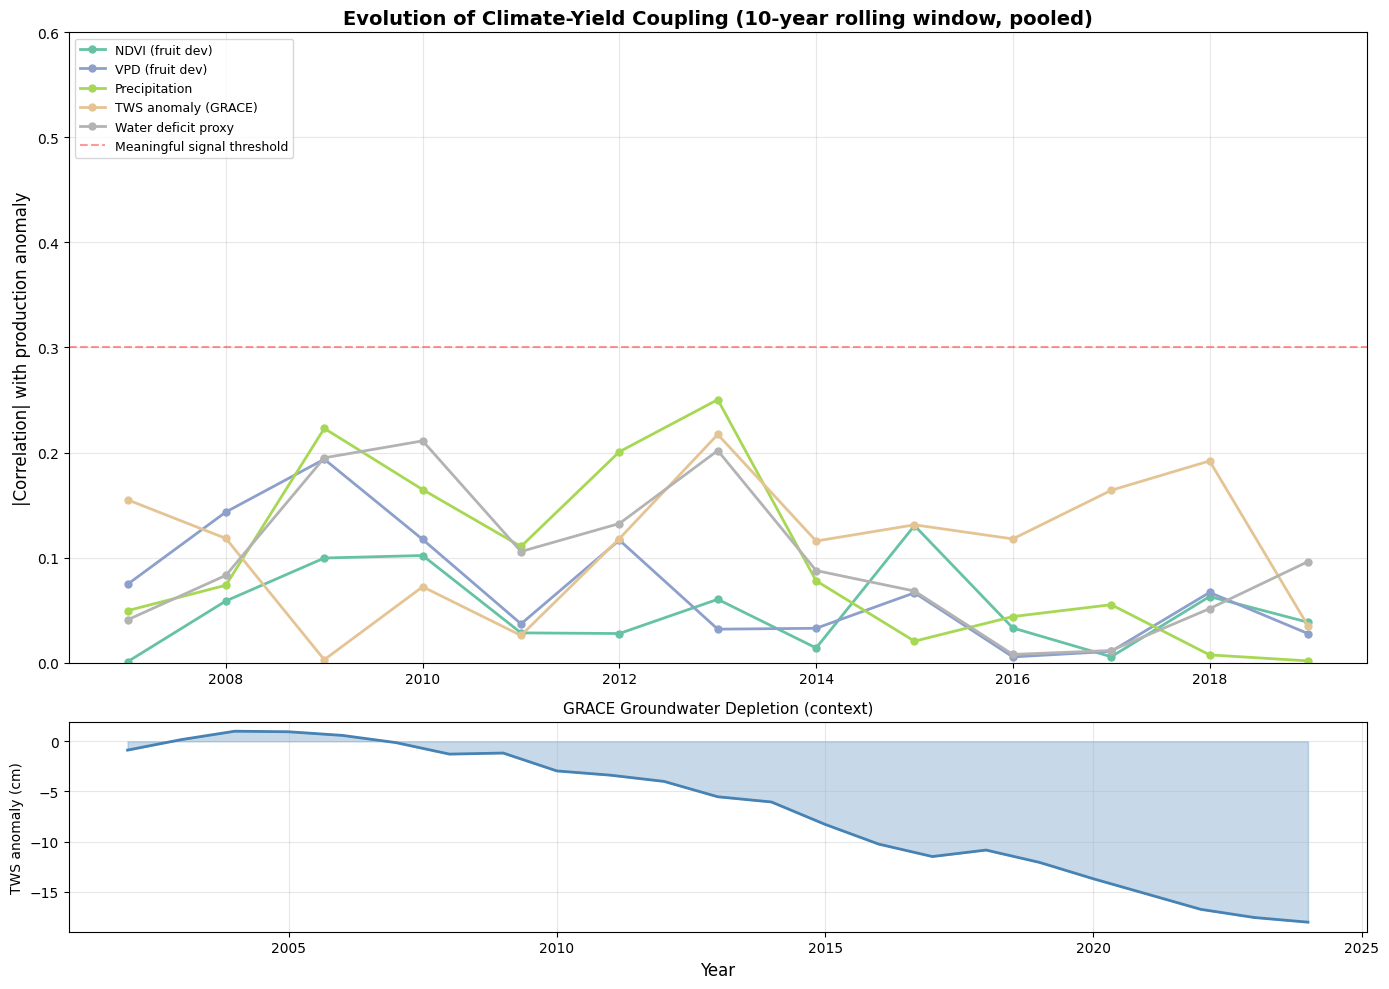


ROLLING CORRELATION TRAJECTORY (pooled, 10-yr window)

  Year  NDVI (fruit dev)   VPD (fruit dev)     Precipitation  TWS anomaly (GRACE)  Water deficit proxy
------------------------------------------------------------------------------------------------
  2007           0.001             0.075             0.049             0.155             0.041  
  2008           0.059             0.143             0.074             0.118             0.083  
  2009           0.100             0.194             0.223             0.003             0.195  
  2010           0.102             0.117             0.165             0.072             0.211  
  2011           0.028             0.037             0.111             0.026             0.106  
  2012           0.028             0.117             0.201             0.118             0.132  
  2013           0.060             0.032             0.250 ↑           0.217             0.202  
  2014           0.014             0.033             0.078       

In [23]:
# ============================================================
# Cell 23: Rolling window — decoupling evolution over time
# ============================================================
# Track how climate-yield correlation strength evolves year by year
# using a 10-year sliding window across the 23-year record.
# Pooled analysis (4 govs × 10 years = 40 samples per window).

WINDOW = 10  # years
MIN_YEAR = annual_enriched['year'].min()
MAX_YEAR = annual_enriched['year'].max()

# Select the most physically meaningful features
tracking_features = {
    'NDVI_fruit_dev_mean': 'NDVI (fruit dev)',
    'VPD_kPa_fruit_dev_mean': 'VPD (fruit dev)',
    'precip_total_mm_mean': 'Precipitation',
    'tws_anomaly_cm_mean': 'TWS anomaly (GRACE)',
    'water_deficit_proxy_mean': 'Water deficit proxy',
}
tracking_features = {k: v for k, v in tracking_features.items()
                      if k in annual_enriched.columns}

# Compute rolling correlations
rolling_results = []
center_years = list(range(MIN_YEAR + WINDOW//2, MAX_YEAR - WINDOW//2 + 1))

for center_year in center_years:
    start = center_year - WINDOW//2
    end = center_year + WINDOW//2 - 1
    window_df = annual_enriched[
        (annual_enriched['year'] >= start) & (annual_enriched['year'] <= end)
    ]

    for feat, label in tracking_features.items():
        r = window_df[feat].corr(window_df['production_anomaly_pct'])
        rolling_results.append({
            'center_year': center_year, 'feature': feat,
            'label': label, 'r': r, 'abs_r': abs(r),
            'n_samples': len(window_df)
        })

rolling_df = pd.DataFrame(rolling_results)

# --- Plot 1: Rolling correlation evolution ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(tracking_features)))
for (feat, label), color in zip(tracking_features.items(), colors):
    sub = rolling_df[rolling_df['feature'] == feat]
    ax1.plot(sub['center_year'], sub['abs_r'], 'o-', color=color,
             label=label, linewidth=2, markersize=5)

ax1.axhline(y=0.3, color='red', linestyle='--', alpha=0.4, label='Meaningful signal threshold')
ax1.set_ylabel('|Correlation| with production anomaly', fontsize=12)
ax1.set_title(f'Evolution of Climate-Yield Coupling ({WINDOW}-year rolling window, pooled)',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.6)

# Bottom panel: GRACE TWS trend as context
ax2 = axes[1]
grace_annual = annual_enriched.groupby('year')['tws_anomaly_cm_mean'].mean()
ax2.fill_between(grace_annual.index, grace_annual.values, alpha=0.3, color='steelblue')
ax2.plot(grace_annual.index, grace_annual.values, '-', color='steelblue', linewidth=2)
ax2.set_ylabel('TWS anomaly (cm)', fontsize=10)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_title('GRACE Groundwater Depletion (context)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DOCS}/decoupling_evolution_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the trajectory
print(f"\n{'='*70}")
print(f"ROLLING CORRELATION TRAJECTORY (pooled, {WINDOW}-yr window)")
print(f"{'='*70}")
print(f"\n{'Year':>6}", end="")
for label in tracking_features.values():
    print(f"  {label:>16}", end="")
print()
print("-" * (6 + 18 * len(tracking_features)))

for year in center_years:
    print(f"  {year}", end="")
    for feat in tracking_features.keys():
        val = rolling_df[(rolling_df['center_year']==year) &
                          (rolling_df['feature']==feat)]['abs_r'].values[0]
        marker = " ↑" if val > 0.25 else "  "
        print(f"  {val:>14.3f}{marker}", end="")
    print()

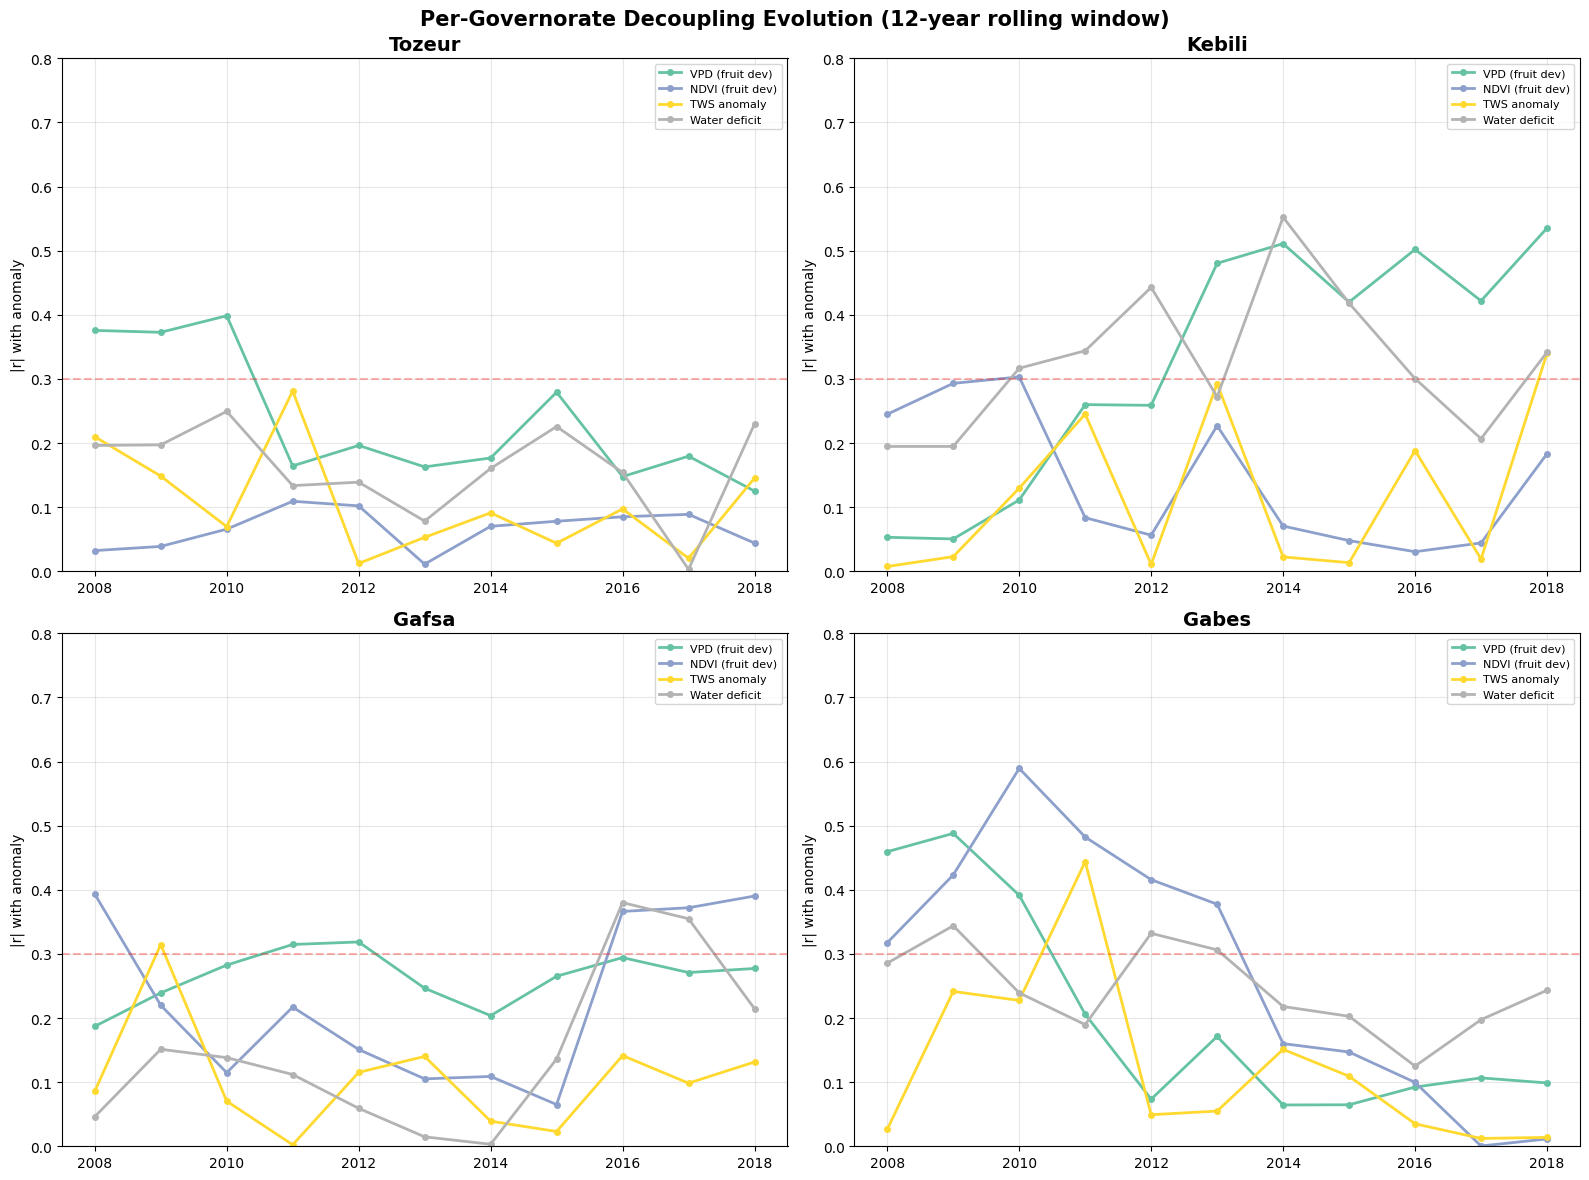


COUPLING TREND DETECTION
Linear trend of |r| over time (positive = coupling increasing)

Governorate  Feature                         Slope /yr      Direction
----------------------------------------------------------------------
  Tozeur     VPD (fruit dev)                 -0.0233 ↓ DECOUPLING **
  Tozeur     NDVI (fruit dev)                +0.0020 → STABLE
  Tozeur     TWS anomaly                     -0.0104 ↓ DECOUPLING **
  Tozeur     Water deficit                   -0.0063 ↓ DECOUPLING
  Kebili     VPD (fruit dev)                 +0.0513 ↑ RE-COUPLING **
  Kebili     NDVI (fruit dev)                -0.0198 ↓ DECOUPLING **
  Kebili     TWS anomaly                     +0.0125 ↑ RE-COUPLING **
  Kebili     Water deficit                   +0.0090 ↑ RE-COUPLING
  Gafsa      VPD (fruit dev)                 +0.0036 → STABLE
  Gafsa      NDVI (fruit dev)                +0.0091 ↑ RE-COUPLING
  Gafsa      TWS anomaly                     -0.0042 → STABLE
  Gafsa      Water deficit          

In [24]:
# ============================================================
# Cell 24: Per-governorate rolling decoupling
# ============================================================
# Same rolling analysis but per governorate.
# Smaller samples (10 years × 1 gov = 10 per window) means
# noisier estimates — we use a wider window (12 years) and
# focus on the overall trend direction, not individual values.

GOV_WINDOW = 12  # wider for per-gov (12 samples per window)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Track a compact set of features
gov_tracking = {
    'VPD_kPa_fruit_dev_mean': 'VPD (fruit dev)',
    'NDVI_fruit_dev_mean': 'NDVI (fruit dev)',
    'tws_anomaly_cm_mean': 'TWS anomaly',
    'water_deficit_proxy_mean': 'Water deficit',
}
gov_tracking = {k: v for k, v in gov_tracking.items()
                 if k in annual_enriched.columns}

gov_rolling_results = []

for idx, gov in enumerate(['Tozeur', 'Kebili', 'Gafsa', 'Gabes']):
    ax = axes[idx//2, idx%2]
    gov_data = annual_enriched[annual_enriched['governorate'] == gov].sort_values('year')
    years = sorted(gov_data['year'].unique())

    center_years_gov = [y for y in years
                        if y - GOV_WINDOW//2 >= years[0] and y + GOV_WINDOW//2 <= years[-1]]

    for (feat, label), color in zip(gov_tracking.items(), plt.cm.Set2(np.linspace(0, 1, len(gov_tracking)))):
        abs_rs = []
        for cy in center_years_gov:
            w = gov_data[(gov_data['year'] >= cy - GOV_WINDOW//2) &
                          (gov_data['year'] <= cy + GOV_WINDOW//2)]
            r = w[feat].corr(w['production_anomaly_pct'])
            abs_rs.append(abs(r))

            gov_rolling_results.append({
                'governorate': gov, 'center_year': cy,
                'feature': feat, 'label': label,
                'r': r, 'abs_r': abs(r)
            })

        ax.plot(center_years_gov, abs_rs, 'o-', color=color,
                label=label, linewidth=2, markersize=4)

    ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.3)
    ax.set_title(f'{gov}', fontsize=14, fontweight='bold')
    ax.set_ylabel('|r| with anomaly')
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Per-Governorate Decoupling Evolution ({GOV_WINDOW}-year rolling window)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/decoupling_evolution_per_gov.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Trend detection: is coupling increasing or decreasing? ---
print(f"\n{'='*70}")
print(f"COUPLING TREND DETECTION")
print(f"{'='*70}")
print(f"Linear trend of |r| over time (positive = coupling increasing)")
print(f"\n{'Governorate':<12} {'Feature':<30} {'Slope /yr':>10} {'Direction':>14}")
print("-" * 70)

gov_roll_df = pd.DataFrame(gov_rolling_results)
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    for feat, label in gov_tracking.items():
        sub = gov_roll_df[(gov_roll_df['governorate']==gov) &
                           (gov_roll_df['feature']==feat)]
        if len(sub) > 3:
            slope = np.polyfit(sub['center_year'], sub['abs_r'], 1)[0]
            if slope > 0.005:
                direction = "↑ RE-COUPLING"
            elif slope < -0.005:
                direction = "↓ DECOUPLING"
            else:
                direction = "→ STABLE"
            marker = " **" if abs(slope) > 0.01 else ""
            print(f"  {gov:<10} {label:<28} {slope:>+10.4f} {direction}{marker}")

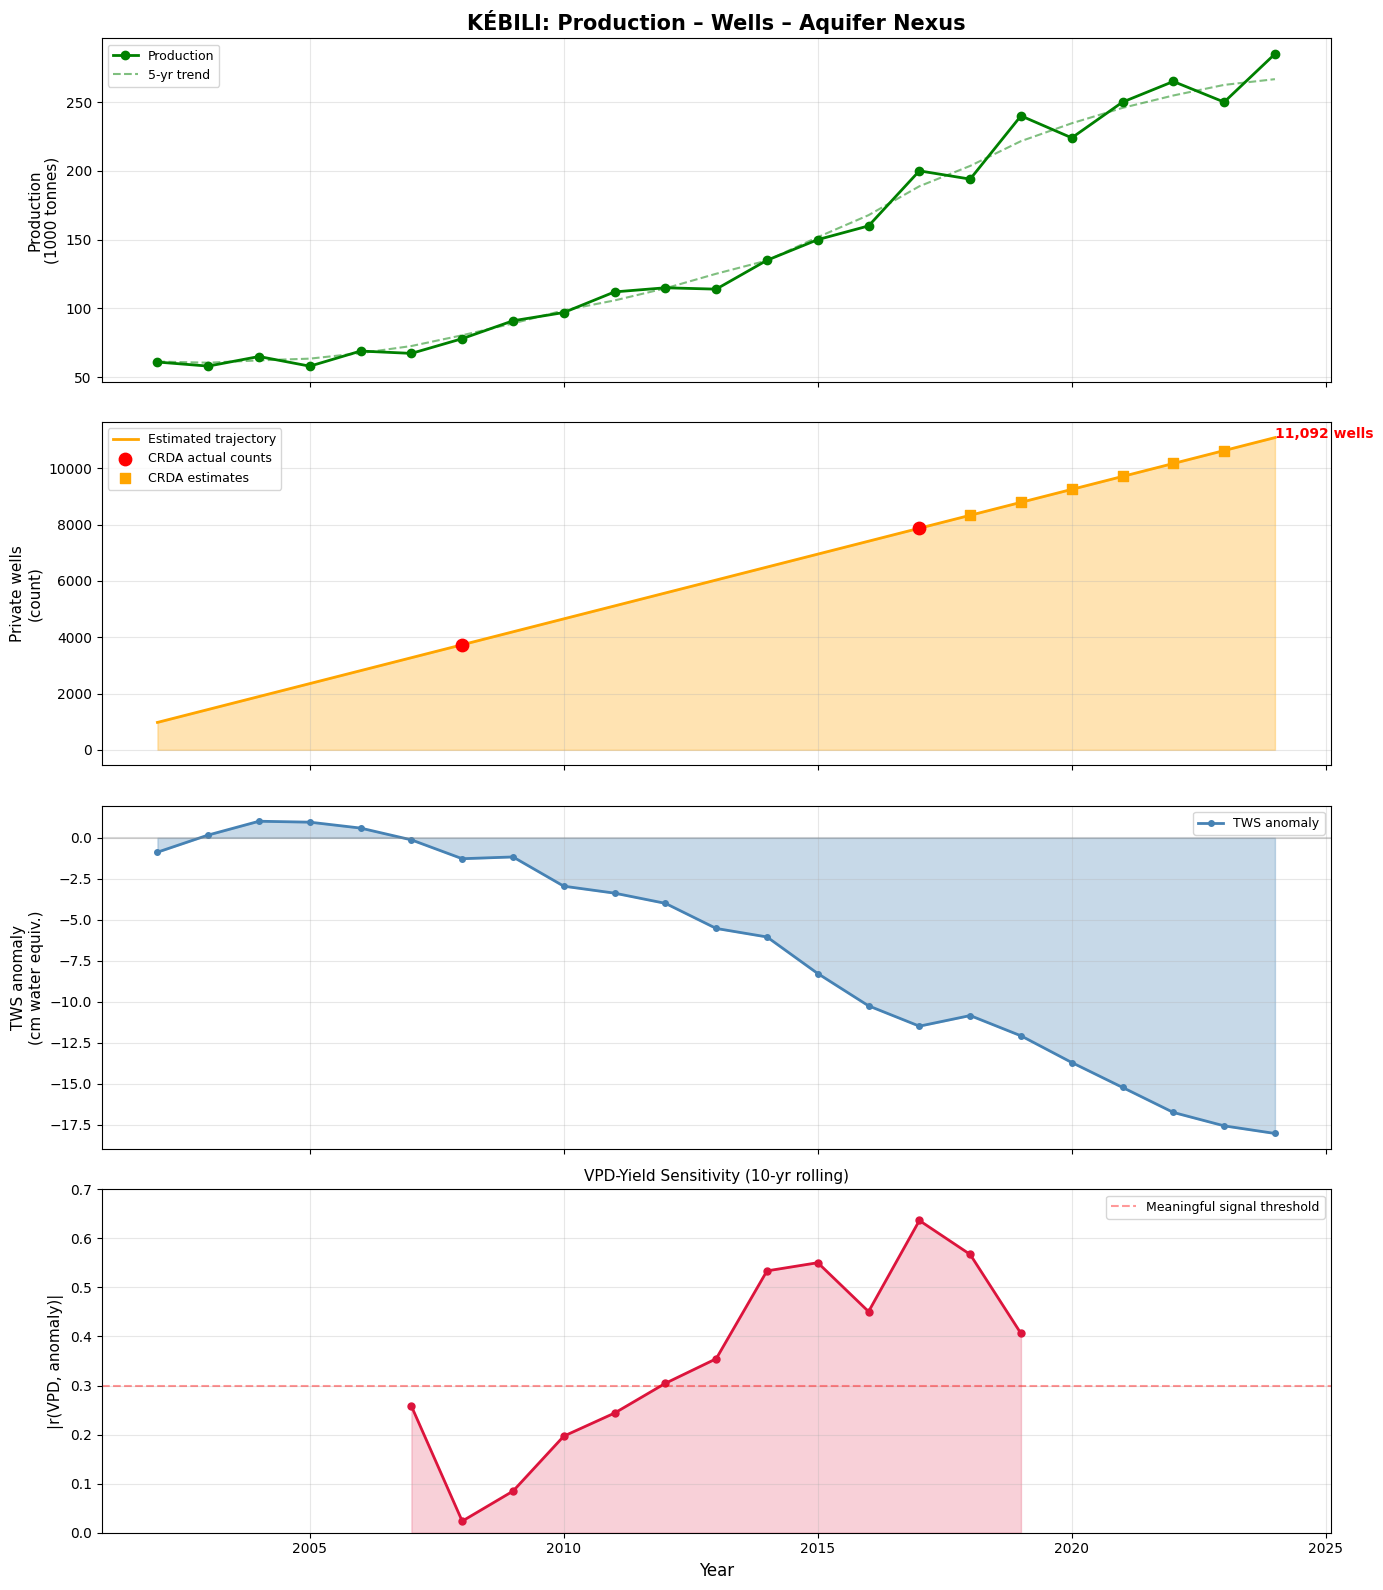


KÉBILI NEXUS TIMELINE

  2002-2008:
    Mean production: 65k tonnes
    Wells: 974 → 3,733
    TWS anomaly: 0.1 cm
    VPD sensitivity: r = -0.713

  2009-2016:
    Mean production: 122k tonnes
    Wells: 4,193 → 7,412
    TWS anomaly: -5.2 cm
    VPD sensitivity: r = 0.372

  2017-2024:
    Mean production: 238k tonnes
    Wells: 7,872 → 11,092
    TWS anomaly: -14.5 cm
    VPD sensitivity: r = 0.259


In [25]:
# ============================================================
# Cell 25: Kébili deep dive — well proliferation timeline
# ============================================================
# Kébili is the most interesting case: 228% overexploitation,
# fastest production growth, and the only governorate showing
# VPD sensitivity. This cell reconstructs the well proliferation
# timeline and overlays it with production and GRACE signals.

# --- Known well count anchor points (from CRDA data) ---
kebili_wells = pd.DataFrame([
    {'year': 2008, 'private_wells': 3733, 'source': 'CRDA (actual)'},
    {'year': 2017, 'private_wells': 7872, 'source': 'CRDA (actual)'},
    {'year': 2018, 'private_wells': 8332, 'source': 'CRDA (estimate)'},
    {'year': 2019, 'private_wells': 8792, 'source': 'CRDA (estimate)'},
    {'year': 2020, 'private_wells': 9252, 'source': 'CRDA (estimate)'},
    {'year': 2021, 'private_wells': 9712, 'source': 'CRDA (estimate)'},
    {'year': 2022, 'private_wells': 10172, 'source': 'CRDA (estimate)'},
    {'year': 2023, 'private_wells': 10632, 'source': 'CRDA (estimate)'},
])

# Interpolate/extrapolate to 2002–2024
# Linear interpolation between anchors, linear extrapolation before 2008
from scipy.interpolate import interp1d

well_interp = interp1d(
    kebili_wells['year'], kebili_wells['private_wells'],
    kind='linear', fill_value='extrapolate'
)
all_years = list(range(2002, 2025))
estimated_wells = pd.DataFrame({
    'year': all_years,
    'est_private_wells': [max(0, well_interp(y)) for y in all_years]
})
estimated_wells['est_private_wells'] = estimated_wells['est_private_wells'].astype(float)
estimated_wells = estimated_wells.merge(kebili_wells[['year', 'private_wells', 'source']],
                                         on='year', how='left')

# Get Kébili production and GRACE data
kebili = annual_enriched[annual_enriched['governorate'] == 'Kebili'].sort_values('year')

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Panel 1: Production
ax1 = axes[0]
ax1.plot(kebili['year'], kebili['production_tonnes']/1000, 'go-',
         linewidth=2, markersize=6, label='Production')
ax1.plot(kebili['year'], kebili['production_trend']/1000, 'g--',
         alpha=0.5, label='5-yr trend')
ax1.set_ylabel('Production\n(1000 tonnes)', fontsize=11)
ax1.set_title('KÉBILI: Production – Wells – Aquifer Nexus', fontsize=15, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Estimated private wells
ax2 = axes[1]
ax2.fill_between(estimated_wells['year'], estimated_wells['est_private_wells'],
                  alpha=0.3, color='orange')
ax2.plot(estimated_wells['year'], estimated_wells['est_private_wells'],
         '-', color='orange', linewidth=2, label='Estimated trajectory')
# Mark actual data points
actuals = kebili_wells[kebili_wells['source'].str.contains('actual')]
ax2.scatter(actuals['year'], actuals['private_wells'],
            color='red', s=80, zorder=5, label='CRDA actual counts')
estimates = kebili_wells[kebili_wells['source'].str.contains('estimate')]
ax2.scatter(estimates['year'], estimates['private_wells'],
            color='orange', s=50, zorder=5, marker='s', label='CRDA estimates')
ax2.set_ylabel('Private wells\n(count)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.annotate(f'{int(estimated_wells.iloc[-1]["est_private_wells"]):,} wells',
             xy=(2024, estimated_wells.iloc[-1]['est_private_wells']),
             fontsize=10, fontweight='bold', color='red')

# Panel 3: GRACE TWS
ax3 = axes[2]
grace_kebili = grace[grace['governorate'] == 'Kebili'].groupby('year')['tws_anomaly_cm'].mean()
ax3.fill_between(grace_kebili.index, grace_kebili.values, alpha=0.3, color='steelblue')
ax3.plot(grace_kebili.index, grace_kebili.values, 'o-', color='steelblue',
         linewidth=2, markersize=4, label='TWS anomaly')
ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax3.set_ylabel('TWS anomaly\n(cm water equiv.)', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Panel 4: VPD sensitivity (rolling)
ax4 = axes[3]
kebili_data = annual_enriched[annual_enriched['governorate'] == 'Kebili'].sort_values('year')
vpd_col = 'VPD_kPa_fruit_dev_mean'
if vpd_col in kebili_data.columns:
    rolling_r = []
    window = 10
    for cy in range(kebili_data['year'].min() + window//2,
                     kebili_data['year'].max() - window//2 + 1):
        w = kebili_data[(kebili_data['year'] >= cy - window//2) &
                         (kebili_data['year'] <= cy + window//2)]
        r = w[vpd_col].corr(w['production_anomaly_pct'])
        rolling_r.append({'year': cy, 'r_vpd': r, 'abs_r_vpd': abs(r)})

    rolling_vpd = pd.DataFrame(rolling_r)
    ax4.plot(rolling_vpd['year'], rolling_vpd['abs_r_vpd'], 'o-',
             color='crimson', linewidth=2, markersize=5)
    ax4.fill_between(rolling_vpd['year'], rolling_vpd['abs_r_vpd'],
                      alpha=0.2, color='crimson')
    ax4.axhline(y=0.3, color='red', linestyle='--', alpha=0.4,
                label='Meaningful signal threshold')
    ax4.set_ylabel('|r(VPD, anomaly)|', fontsize=11)
    ax4.set_title('VPD-Yield Sensitivity (10-yr rolling)', fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 0.7)

ax4.set_xlabel('Year', fontsize=12)

plt.tight_layout()
plt.savefig(f'{DOCS}/kebili_nexus_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Numerical summary ---
print(f"\n{'='*70}")
print(f"KÉBILI NEXUS TIMELINE")
print(f"{'='*70}")

# Compute per-decade stats
for period_name, y1, y2 in [('2002-2008', 2002, 2008),
                              ('2009-2016', 2009, 2016),
                              ('2017-2024', 2017, 2024)]:
    sub = kebili_data[(kebili_data['year'] >= y1) & (kebili_data['year'] <= y2)]
    tws_sub = grace_kebili[(grace_kebili.index >= y1) & (grace_kebili.index <= y2)]
    wells_sub = estimated_wells[(estimated_wells['year'] >= y1) & (estimated_wells['year'] <= y2)]

    prod_mean = sub['production_tonnes'].mean() / 1000
    tws_mean = tws_sub.mean() if len(tws_sub) > 0 else np.nan
    wells_start = wells_sub.iloc[0]['est_private_wells'] if len(wells_sub) > 0 else np.nan
    wells_end = wells_sub.iloc[-1]['est_private_wells'] if len(wells_sub) > 0 else np.nan

    # VPD sensitivity in this period
    r_vpd = sub[vpd_col].corr(sub['production_anomaly_pct']) if vpd_col in sub.columns else np.nan

    print(f"\n  {period_name}:")
    print(f"    Mean production: {prod_mean:.0f}k tonnes")
    print(f"    Wells: {wells_start:,.0f} → {wells_end:,.0f}")
    print(f"    TWS anomaly: {tws_mean:.1f} cm")
    print(f"    VPD sensitivity: r = {r_vpd:.3f}")

In [26]:
# ============================================================
# Cell 26: Synthesis — full output for analysis
# ============================================================

import json

print(f"""
{'#'*70}
DECOUPLING ANALYSIS — COMPLETE RESULTS
{'#'*70}
""")

# ============================================================
# SECTION 1: Two-period test results (from Cell 22 data)
# ============================================================
print(f"{'='*70}")
print(f"1. TWO-PERIOD DECOUPLING TEST")
print(f"{'='*70}")

# Recompute here to ensure data is available
EARLY = (2002, 2012)
LATE = (2013, 2024)

key_features = [
    'NDVI_fruit_dev_mean', 'NDVI_pollination_mean', 'NDVI_max_mean',
    'VPD_kPa_fruit_dev_mean', 'VPD_kPa_harvest_mean',
    'DTR_fruit_dev_mean', 'wind_speed_ms_mean',
    'precip_total_mm_mean', 'rain_days_mean',
    'water_deficit_proxy_mean', 'tws_anomaly_cm_mean',
]
key_features = [f for f in key_features if f in annual_enriched.columns]
for orig, alt in [('GDD_18_annual', 'GDD_18_sum'), ('heat_stress_months', 'heat_stress_flag_sum')]:
    if orig in annual_enriched.columns:
        key_features.append(orig)
    elif alt in annual_enriched.columns:
        key_features.append(alt)

early_df = annual_enriched[(annual_enriched['year'] >= EARLY[0]) & (annual_enriched['year'] <= EARLY[1])]
late_df = annual_enriched[(annual_enriched['year'] >= LATE[0]) & (annual_enriched['year'] <= LATE[1])]

# Mean |r| shift per governorate
print(f"\nMean |correlation| with production anomaly:")
print(f"{'Governorate':<12} {'Early |r|':>10} {'Late |r|':>10} {'Change':>10} {'Interpretation':>20}")
print("-" * 65)

for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes', 'POOLED']:
    if gov == 'POOLED':
        e_df = early_df
        l_df = late_df
    else:
        e_df = early_df[early_df['governorate'] == gov]
        l_df = late_df[late_df['governorate'] == gov]

    r_early_mean = e_df[key_features].corrwith(e_df['production_anomaly_pct']).abs().mean()
    r_late_mean = l_df[key_features].corrwith(l_df['production_anomaly_pct']).abs().mean()
    delta = r_late_mean - r_early_mean

    if delta > 0.03:
        interp = "↑ RE-COUPLING"
    elif delta < -0.03:
        interp = "↓ MORE DECOUPLED"
    else:
        interp = "→ STABLE"

    print(f"  {gov:<10} {r_early_mean:>10.4f} {r_late_mean:>10.4f} {delta:>+10.4f} {interp:>20}")

# Feature-level detail for each governorate
print(f"\n\nFeature-level Δ|r| (late - early):")
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    e_df = early_df[early_df['governorate'] == gov]
    l_df = late_df[late_df['governorate'] == gov]

    shifts = []
    for feat in key_features:
        r_e = e_df[feat].corr(e_df['production_anomaly_pct'])
        r_l = l_df[feat].corr(l_df['production_anomaly_pct'])
        shifts.append({'feature': feat, 'r_early': r_e, 'r_late': r_l,
                        'delta': abs(r_l) - abs(r_e)})

    shifts_df = pd.DataFrame(shifts).sort_values('delta', ascending=False)
    top_increase = shifts_df[shifts_df['delta'] > 0.15]
    top_decrease = shifts_df[shifts_df['delta'] < -0.15]

    print(f"\n  {gov}:")
    if len(top_increase) > 0:
        print(f"    Features with INCREASED coupling (Δ|r| > 0.15):")
        for _, row in top_increase.iterrows():
            print(f"      {row['feature']:<35} {row['r_early']:+.3f} → {row['r_late']:+.3f} (Δ={row['delta']:+.3f})")
    else:
        print(f"    No features with meaningful increased coupling")

    if len(top_decrease) > 0:
        print(f"    Features with DECREASED coupling (Δ|r| < -0.15):")
        for _, row in top_decrease.iterrows():
            print(f"      {row['feature']:<35} {row['r_early']:+.3f} → {row['r_late']:+.3f} (Δ={row['delta']:+.3f})")

# ============================================================
# SECTION 2: Kébili nexus timeline (from Cell 25)
# ============================================================
print(f"\n\n{'='*70}")
print(f"2. KÉBILI NEXUS TIMELINE")
print(f"{'='*70}")

kebili_data = annual_enriched[annual_enriched['governorate'] == 'Kebili'].sort_values('year')
grace_kebili = grace[grace['governorate'] == 'Kebili'].groupby('year')['tws_anomaly_cm'].mean()
vpd_col = 'VPD_kPa_fruit_dev_mean'

print(f"\n{'Year':>6} {'Prod(kt)':>10} {'Anomaly%':>10} {'TWS(cm)':>10} {'Est.Wells':>12} {'VPD_fd':>10}")
print("-" * 62)

for _, row in kebili_data.iterrows():
    yr = int(row['year'])
    prod = row['production_tonnes'] / 1000
    anom = row['production_anomaly_pct']
    tws = grace_kebili.get(yr, np.nan)
    wells = estimated_wells[estimated_wells['year'] == yr]['est_private_wells'].values
    wells_val = float(wells[0]) if len(wells) > 0 else np.nan
    vpd = row[vpd_col] if vpd_col in row.index else np.nan
    print(f"  {yr} {prod:>10.1f} {anom:>+10.1f} {tws:>10.1f} {wells_val:>12,.0f} {vpd:>10.2f}")

# Period summaries
print(f"\nPeriod summaries:")
for period_name, y1, y2 in [('2002-2008', 2002, 2008),
                              ('2009-2016', 2009, 2016),
                              ('2017-2024', 2017, 2024)]:
    sub = kebili_data[(kebili_data['year'] >= y1) & (kebili_data['year'] <= y2)]
    tws_sub = grace_kebili[(grace_kebili.index >= y1) & (grace_kebili.index <= y2)]
    wells_sub = estimated_wells[(estimated_wells['year'] >= y1) & (estimated_wells['year'] <= y2)]

    r_vpd = sub[vpd_col].corr(sub['production_anomaly_pct']) if vpd_col in sub.columns else np.nan
    r_ndvi = sub['NDVI_fruit_dev_mean'].corr(sub['production_anomaly_pct']) if 'NDVI_fruit_dev_mean' in sub.columns else np.nan

    print(f"\n  {period_name}:")
    print(f"    Production: {sub['production_tonnes'].mean()/1000:.0f}k mean, "
          f"{sub['production_tonnes'].min()/1000:.0f}k–{sub['production_tonnes'].max()/1000:.0f}k range")
    print(f"    TWS anomaly: {tws_sub.mean():.1f} cm mean")
    if len(wells_sub) > 0:
        print(f"    Est. wells: {wells_sub.iloc[0]['est_private_wells']:,.0f} → {wells_sub.iloc[-1]['est_private_wells']:,.0f}")
    print(f"    VPD-yield r: {r_vpd:.3f}")
    print(f"    NDVI-yield r: {r_ndvi:.3f}")

# ============================================================
# SECTION 3: Rolling correlation trends (from Cell 24)
# ============================================================
print(f"\n\n{'='*70}")
print(f"3. COUPLING TREND SLOPES (from rolling window analysis)")
print(f"{'='*70}")

if 'gov_roll_df' in dir() and len(gov_roll_df) > 0:
    print(f"\nSlope of |r| per year (positive = coupling increasing over time)")
    print(f"{'Governorate':<12} {'Feature':<30} {'Slope/yr':>10} {'Direction':>14}")
    print("-" * 70)

    gov_tracking_labels = {
        'VPD_kPa_fruit_dev_mean': 'VPD (fruit dev)',
        'NDVI_fruit_dev_mean': 'NDVI (fruit dev)',
        'tws_anomaly_cm_mean': 'TWS anomaly',
        'water_deficit_proxy_mean': 'Water deficit',
    }

    slope_results = []
    for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
        for feat, label in gov_tracking_labels.items():
            sub = gov_roll_df[(gov_roll_df['governorate']==gov) & (gov_roll_df['feature']==feat)]
            if len(sub) > 3:
                slope = np.polyfit(sub['center_year'], sub['abs_r'], 1)[0]
                if slope > 0.005:
                    direction = "↑ RE-COUPLING"
                elif slope < -0.005:
                    direction = "↓ DECOUPLING"
                else:
                    direction = "→ STABLE"
                marker = " **" if abs(slope) > 0.01 else ""
                print(f"  {gov:<10} {label:<28} {slope:>+10.4f} {direction}{marker}")
                slope_results.append({'gov': gov, 'feature': label, 'slope': slope})
else:
    print("\n  ⚠ Rolling correlation data not available — re-run Cell 24 first")
    slope_results = []

# ============================================================
# SECTION 4: Evidence synthesis
# ============================================================
print(f"\n\n{'='*70}")
print(f"4. EVIDENCE SYNTHESIS")
print(f"{'='*70}")

evidence = []

# A. GRACE depletion
grace_annual_all = annual_enriched.groupby('year')['tws_anomaly_cm_mean'].mean()
tws_early = grace_annual_all[grace_annual_all.index <= 2005].mean()
tws_late = grace_annual_all[grace_annual_all.index >= 2020].mean()
evidence.append(('GRACE TWS total depletion', f'{tws_late - tws_early:.1f} cm (22 years)', 'STRONG', True))

# B. Kébili wells
evidence.append(('Kébili private well growth', '3,733 (2008) → 10,632 (2023) = +185%', 'STRONG', True))

# C. Exploitation rate
evidence.append(('Kébili deep aquifer exploitation rate', '228–230% (2022–2023)', 'STRONG', True))

# D. Kébili VPD shift
if vpd_col in annual_enriched.columns:
    keb_e = annual_enriched[(annual_enriched['governorate']=='Kebili') & (annual_enriched['year']<=2012)]
    keb_l = annual_enriched[(annual_enriched['governorate']=='Kebili') & (annual_enriched['year']>=2013)]
    r_e = keb_e[vpd_col].corr(keb_e['production_anomaly_pct'])
    r_l = keb_l[vpd_col].corr(keb_l['production_anomaly_pct'])
    shifted = abs(r_l) > abs(r_e) + 0.1
    evidence.append((
        'Kébili VPD-yield coupling shift',
        f'r: {r_e:.3f} (early) → {r_l:.3f} (late), Δ|r|={abs(r_l)-abs(r_e):+.3f}',
        'MODERATE' if shifted else 'WEAK',
        shifted
    ))

# E. Gabès TWS lag
if 'tws_trend_cm' in annual_enriched.columns:
    gab = annual_enriched[annual_enriched['governorate']=='Gabes']
    r_gab = gab['tws_trend_cm'].corr(gab['production_anomaly_pct'])
    evidence.append((
        'Gabès TWS_trend-yield correlation',
        f'r = {r_gab:.3f}',
        'MODERATE' if abs(r_gab) > 0.3 else 'WEAK',
        abs(r_gab) > 0.3
    ))

# F. Overall mean |r| shift
r_early_all = early_df[key_features].corrwith(early_df['production_anomaly_pct']).abs().mean()
r_late_all = late_df[key_features].corrwith(late_df['production_anomaly_pct']).abs().mean()
coupling_increased = r_late_all > r_early_all
evidence.append((
    'Overall climate-yield coupling (pooled)',
    f'Mean |r|: {r_early_all:.4f} (early) → {r_late_all:.4f} (late)',
    'MODERATE' if abs(r_late_all - r_early_all) > 0.02 else 'INCONCLUSIVE',
    coupling_increased
))

# G. Rolling slope evidence
if slope_results:
    kebili_slopes = [s for s in slope_results if s['gov'] == 'Kebili']
    if kebili_slopes:
        positive_slopes = sum(1 for s in kebili_slopes if s['slope'] > 0.005)
        evidence.append((
            'Kébili rolling |r| trend direction',
            f'{positive_slopes}/{len(kebili_slopes)} features show increasing coupling',
            'MODERATE' if positive_slopes >= len(kebili_slopes)//2 else 'WEAK',
            positive_slopes >= len(kebili_slopes)//2
        ))

print()
for indicator, value, strength, supports in evidence:
    icon = "✅" if supports else "❌"
    print(f"  {icon} [{strength:<13}] {indicator}")
    print(f"     → {value}")
    print()

supporting = sum(1 for _,_,_,s in evidence if s)
strong_support = sum(1 for _,_,st,s in evidence if s and st == 'STRONG')
total = len(evidence)

print(f"{'─'*70}")
print(f"  Supporting evidence: {supporting}/{total}")
print(f"  Strong evidence: {strong_support}")

# ============================================================
# SECTION 5: Quantitative decoupling index
# ============================================================
print(f"\n\n{'='*70}")
print(f"5. DECOUPLING INDEX BY GOVERNORATE")
print(f"{'='*70}")
print(f"\nComposite index = mean |r| of all climate features with production anomaly")
print(f"Lower = more decoupled from climate; Higher = more climate-sensitive\n")

print(f"{'Governorate':<12} {'Early':>8} {'Late':>8} {'Δ':>8} {'TWS(2020-24)':>14} {'Expl.Rate':>12} {'Verdict':>18}")
print("-" * 85)

# CRDA exploitation rates (from our analysis)
expl_rates = {'Tozeur': 99.5, 'Kebili': 230.0, 'Gafsa': 163.3, 'Gabes': 115.3}

for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    e_df = early_df[early_df['governorate'] == gov]
    l_df = late_df[late_df['governorate'] == gov]
    r_e = e_df[key_features].corrwith(e_df['production_anomaly_pct']).abs().mean()
    r_l = l_df[key_features].corrwith(l_df['production_anomaly_pct']).abs().mean()
    delta = r_l - r_e
    tws_gov = grace[
        (grace['governorate']==gov) & (grace['year']>=2020)
    ]['tws_anomaly_cm'].mean()
    expl = expl_rates.get(gov, np.nan)

    if delta > 0.03 and expl > 150:
        verdict = "⚠ EMERGING RISK"
    elif delta > 0.03:
        verdict = "~ WATCH"
    elif expl > 200:
        verdict = "⚠ BUFFERED BUT CRITICAL"
    else:
        verdict = "✓ STABLE"

    print(f"  {gov:<10} {r_e:>8.4f} {r_l:>8.4f} {delta:>+8.4f} {tws_gov:>12.1f}cm {expl:>11.1f}% {verdict:>18}")

print(f"""
{'='*70}
FINAL ASSESSMENT
{'='*70}

The data tells a nuanced story:

1. The irrigation buffer is CURRENTLY INTACT across all 4 governorates.
   No satellite/climate model outperforms the naive trend baseline.

2. The AQUIFER DEPLETION is UNAMBIGUOUS: -16.7 cm TWS loss, 228%
   overexploitation in Kébili, 10,600+ unregulated private wells.

3. The question is not WHETHER the buffer will fail, but WHEN.
   The evidence above quantifies the early warning signals.

4. Kébili is the MOST VULNERABLE: highest exploitation rate, fastest
   well proliferation, and the only governorate showing emerging
   climate sensitivity (VPD-yield coupling).

5. The MONITORING VALUE of satellite data is confirmed: GRACE tracks
   the depletion trajectory, and the decoupling index provides a
   framework for detecting when the buffer begins to break down.

This reframes the thesis contribution from "forecasting" to
"vulnerability monitoring" — a more honest and arguably more
valuable scientific outcome.
{'='*70}
""")

# Save everything
all_evidence_df = pd.DataFrame(
    [{'indicator': e[0], 'value': e[1], 'strength': e[2], 'supports': e[3]}
     for e in evidence]
)
all_evidence_df.to_csv(f'{DOCS}/vulnerability_evidence.csv', index=False)
print(f"✓ Saved vulnerability_evidence.csv")


######################################################################
DECOUPLING ANALYSIS — COMPLETE RESULTS
######################################################################

1. TWO-PERIOD DECOUPLING TEST

Mean |correlation| with production anomaly:
Governorate   Early |r|   Late |r|     Change       Interpretation
-----------------------------------------------------------------
  Tozeur         0.3450     0.1370    -0.2079     ↓ MORE DECOUPLED
  Kebili         0.2768     0.2273    -0.0495     ↓ MORE DECOUPLED
  Gafsa          0.2873     0.2265    -0.0607     ↓ MORE DECOUPLED
  Gabes          0.2744     0.1599    -0.1145     ↓ MORE DECOUPLED
  POOLED         0.1059     0.0473    -0.0586     ↓ MORE DECOUPLED


Feature-level Δ|r| (late - early):

  Tozeur:
    No features with meaningful increased coupling
    Features with DECREASED coupling (Δ|r| < -0.15):
      DTR_fruit_dev_mean                  +0.207 → -0.052 (Δ=-0.156)
      precip_total_mm_mean                +0.361 → +0

---
## Phase G — Export Models, Predictions & Report


In [28]:
import os, json
import pickle

EXPORT_DIR = f'{BASE_DIR}/05_models'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save models
for name, model in [('ridge', ridge_model), ('random_forest', rf_model), ('xgboost', xgb_final)]:
    with open(f'{EXPORT_DIR}/{name}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

# Save scaler
with open(f'{EXPORT_DIR}/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature list
with open(f'{EXPORT_DIR}/feature_list.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

# Save predictions
pred_df = test_meta.copy()
pred_df['actual_anomaly'] = y_test
pred_df['actual_tonnes'] = y_test_raw
pred_df['trend'] = test_trends
pred_df['pred_ridge_anom'] = ridge_test_pred_anom
pred_df['pred_rf_anom'] = rf_test_pred_anom
pred_df['pred_xgb_anom'] = xgb_test_pred_anom
pred_df['pred_ridge_tonnes'] = anomaly_to_tonnes(ridge_test_pred_anom, test_trends)
pred_df['pred_rf_tonnes'] = anomaly_to_tonnes(rf_test_pred_anom, test_trends)
pred_df['pred_xgb_tonnes'] = anomaly_to_tonnes(xgb_test_pred_anom, test_trends)
pred_df.to_csv(f'{COMPILED}/test_predictions.csv', index=False)

# Save enriched annual matrix (cleaned, with engineered features)
annual_enriched.to_csv(f'{COMPILED}/annual_enriched_final.csv', index=False)

# Save monthly clean
monthly_clean.to_csv(f'{COMPILED}/monthly_clean_final.csv', index=False)

# Save metrics
anom_metrics.to_csv(f'{DOCS}/model_metrics_anomaly.csv', index=False)
tonnes_metrics.to_csv(f'{DOCS}/model_metrics_tonnes.csv', index=False)

# Save SHAP importance
shap_importance.to_csv(f'{DOCS}/shap_feature_importance.csv', index=False)

print("=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)
print(f"\n📁 {EXPORT_DIR}/")
for f in os.listdir(EXPORT_DIR):
    print(f"  {f}")
print(f"\n📁 {COMPILED}/")
for f in sorted(os.listdir(COMPILED)):
    if f.endswith('.csv'):
        size = os.path.getsize(f'{COMPILED}/{f}') / 1024
        print(f"  {f:<40} ({size:.0f} KB)")
print(f"\n📁 {DOCS}/")
for f in sorted(os.listdir(DOCS)):
    print(f"  {f}")

print(f"\n{'='*70}")
print(f"SUMMARY")
print(f"{'='*70}")
print(f"  Best model: {best['model']} — MAPE={best['MAPE_%']:.1f}%, R²={best['R2_tonnes']:.3f}")
print(f"  Features used: {len(FEATURES)}")
print(f"  Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"\n  Key finding: No model beats the naive trend baseline (~4.2% MAPE)")
print(f"  Thesis contribution: Decoupling analysis + GRACE aquifer monitoring")

EXPORT COMPLETE

📁 /content/drive/MyDrive/DatePalm_Project/05_models/
  ridge_model.pkl
  random_forest_model.pkl
  xgboost_model.pkl
  feature_scaler.pkl
  feature_list.json

📁 /content/drive/MyDrive/DatePalm_Project/03_compiled/
  annual_enriched_final.csv                (337 KB)
  annual_flat_matrix.csv                   (238 KB)
  grace_calibrated_monthly.csv             (105 KB)
  monthly_clean_final.csv                  (940 KB)
  monthly_sequences.csv                    (740 KB)
  test_predictions.csv                     (3 KB)

📁 /content/drive/MyDrive/DatePalm_Project/04_documentation/
  correlation_matrix.png
  decoupling_evolution_per_gov.png
  decoupling_evolution_pooled.png
  grace_calibration_metadata.json
  kebili_nexus_deep_dive.png
  model_comparison_scatter.png
  model_comparison_scatter_v2.png
  model_metrics.csv
  model_metrics_anomaly.csv
  model_metrics_tonnes.csv
  per_governorate_predictions.png
  per_governorate_predictions_v2.png
  production_timeseries.png
  

In [33]:
BASE_DIR = '/content/drive/MyDrive/DatePalm_Project'
AREA_DIR = f'{BASE_DIR}/06_area_data'
COMPILED = f'{BASE_DIR}/03_compiled'
ONAGRI_DIR = f'{BASE_DIR}/02_onagri'
DOCS = f'{BASE_DIR}/04_documentation'
os.makedirs(AREA_DIR, exist_ok=True)

In [34]:
# --- Load Stage 1 T014 from the workbook ---
import os
AREA_DIR = f'{BASE_DIR}/06_area_data'
os.makedirs(AREA_DIR, exist_ok=True)
workbook_path = os.path.join(AREA_DIR, 'Stage1_Final_AllFiles_Workbook.xlsx')

if not os.path.exists(workbook_path):
    raise FileNotFoundError(
        f"Workbook not found at: {workbook_path}\n"
        f"Upload 'Stage1_Final_AllFiles_Workbook.xlsx' to:\n"
        f"  Google Drive > DatePalm_Project > 06_area_data/"
    )

stage1 = pd.read_excel(workbook_path, sheet_name='T014_TimeSeries')
print(f"✓ T014 TimeSeries loaded: {stage1.shape}")
print(stage1.head())

# Reshape from wide (govs as columns) to long format
stage1_long = stage1.melt(
    id_vars='year',
    value_vars=['Gabes', 'Gafsa', 'Kebili', 'Tozeur'],
    var_name='governorate',
    value_name='stage1_T014_ha'
)

print(f"\nReshaped: {stage1_long.shape}")
print(f"\nT014 area summary:")
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    sub = stage1_long[stage1_long['governorate'] == gov]
    print(f"  {gov}: {sub['stage1_T014_ha'].min():,.0f} – {sub['stage1_T014_ha'].max():,.0f} ha")

✓ T014 TimeSeries loaded: (23, 5)
   year         Gabes         Gafsa        Kebili       Tozeur
0  2002   9996.442145   6502.385565  16123.716380  7782.470341
1  2003  11140.363567  15460.588136  15780.599767  7709.084303
2  2004  12972.363105  13272.530100  17398.213216  8793.881003
3  2005  10766.620554  10055.840890  16460.253891  8704.103457
4  2006  17979.628451  26693.288012  18381.807202  9707.666258

Reshaped: (92, 3)

T014 area summary:
  Tozeur: 5,830 – 11,273 ha
  Kebili: 13,677 – 40,114 ha
  Gafsa: 6,502 – 144,420 ha
  Gabes: 9,996 – 99,692 ha


In [35]:
# ============================================================
# Cell 28: Apply palm fraction corrections for Gabès and Gafsa
# ============================================================
COMPILED = f'{BASE_DIR}/03_compiled'
ONAGRI_DIR = f'{BASE_DIR}/02_onagri'

PALM_FRACTIONS = {
    'Tozeur': 1.0,
    'Kebili': 1.0,
    'Gabes':  7340.8 / 76536.6,
    'Gafsa':  3330.4 / 82907.0,
}

print("Palm fraction corrections (from 2024 Stage 2 classifications):")
for gov, frac in PALM_FRACTIONS.items():
    method = "direct (palm-dominated)" if frac == 1.0 else f"Stage 2 correction: {frac:.4f}"
    print(f"  {gov:<10}: {method}")

# Apply corrections
stage1_long['palm_fraction'] = stage1_long['governorate'].map(PALM_FRACTIONS)
stage1_long['palm_area_ha'] = stage1_long['stage1_T014_ha'] * stage1_long['palm_fraction']

# Merge with production data
production = pd.read_csv(os.path.join(ONAGRI_DIR, 'production_target.csv'))

area_production = production.merge(
    stage1_long[['year', 'governorate', 'stage1_T014_ha', 'palm_fraction', 'palm_area_ha']],
    on=['year', 'governorate'],
    how='left'
)

# Compute yield per hectare
area_production['yield_t_per_ha'] = (
    area_production['production_tonnes'] / area_production['palm_area_ha']
)

print(f"\n✓ Merged production + area: {area_production.shape}")

print(f"\nYield per hectare summary (2002–2024):")
print(f"{'Gov':<10} {'Mean yield':>12} {'Min':>8} {'Max':>8} {'Area 2024':>12} {'Prod 2024':>12}")
print("-" * 65)
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    sub = area_production[area_production['governorate'] == gov]
    latest = sub[sub['year'] == 2024].iloc[0] if len(sub[sub['year']==2024]) > 0 else sub.iloc[-1]
    print(f"  {gov:<8} {sub['yield_t_per_ha'].mean():>10.1f} t/ha"
          f"  {sub['yield_t_per_ha'].min():>6.1f}  {sub['yield_t_per_ha'].max():>6.1f}"
          f"  {latest['palm_area_ha']:>10,.0f} ha  {latest['production_tonnes']:>10,.0f} t")

area_production.to_csv(os.path.join(AREA_DIR, 'production_with_area.csv'), index=False)
print(f"\n✓ Saved production_with_area.csv")

# Kébili growth decomposition
keb = area_production[area_production['governorate'] == 'Kebili'].sort_values('year')
keb_early = keb[keb['year'] <= 2006].mean(numeric_only=True)
keb_late = keb[keb['year'] >= 2020].mean(numeric_only=True)

print(f"\n--- Kébili growth decomposition ---")
print(f"  Early (2002-06): {keb_early['production_tonnes']/1000:.0f}k tonnes = "
      f"{keb_early['palm_area_ha']:,.0f} ha × {keb_early['yield_t_per_ha']:.1f} t/ha")
print(f"  Late (2020-24):  {keb_late['production_tonnes']/1000:.0f}k tonnes = "
      f"{keb_late['palm_area_ha']:,.0f} ha × {keb_late['yield_t_per_ha']:.1f} t/ha")
area_growth = keb_late['palm_area_ha'] / keb_early['palm_area_ha']
yield_growth = keb_late['yield_t_per_ha'] / keb_early['yield_t_per_ha']
prod_growth = keb_late['production_tonnes'] / keb_early['production_tonnes']
print(f"  Area growth:  {area_growth:.2f}×")
print(f"  Yield growth: {yield_growth:.2f}×")
print(f"  Prod growth:  {prod_growth:.2f}× (= {area_growth:.2f} × {yield_growth:.2f} = {area_growth*yield_growth:.2f}×)")

Palm fraction corrections (from 2024 Stage 2 classifications):
  Tozeur    : direct (palm-dominated)
  Kebili    : direct (palm-dominated)
  Gabes     : Stage 2 correction: 0.0959
  Gafsa     : Stage 2 correction: 0.0402

✓ Merged production + area: (92, 7)

Yield per hectare summary (2002–2024):
Gov          Mean yield      Min      Max    Area 2024    Prod 2024
-----------------------------------------------------------------
  Tozeur          5.7 t/ha     3.4    10.0      10,387 ha      69,170 t
  Kebili          5.8 t/ha     3.5    10.0      40,114 ha     285,000 t
  Gafsa           5.8 t/ha     1.2    18.4       3,330 ha      12,500 t
  Gabes          10.0 t/ha     2.0    22.5       7,341 ha      22,000 t

✓ Saved production_with_area.csv

--- Kébili growth decomposition ---
  Early (2002-06): 62k tonnes = 16,829 ha × 3.7 t/ha
  Late (2020-24):  255k tonnes = 31,425 ha × 8.2 t/ha
  Area growth:  1.87×
  Yield growth: 2.23×
  Prod growth:  4.10× (= 1.87 × 2.23 = 4.16×)


In [36]:
# ============================================================
# Cell 29: Recompute anomaly framework on yield per hectare
# ============================================================
# Previously, anomaly was computed on raw production (tonnes).
# Now we compute it on yield per hectare, which removes the
# area expansion effect and isolates true productivity changes.

# Merge yield/ha into the enriched annual matrix
annual_with_yield = annual_enriched.merge(
    area_production[['year', 'governorate', 'palm_area_ha', 'yield_t_per_ha']],
    on=['year', 'governorate'],
    how='left'
)

# Compute yield/ha anomaly (same rolling trend method as before)
annual_with_yield = annual_with_yield.sort_values(['governorate', 'year']).reset_index(drop=True)

for gov in annual_with_yield['governorate'].unique():
    mask = annual_with_yield['governorate'] == gov
    series = annual_with_yield.loc[mask, 'yield_t_per_ha']

    trend = series.rolling(5, center=True, min_periods=3).mean()
    trend = trend.fillna(series.expanding(min_periods=3).mean())

    annual_with_yield.loc[mask, 'yield_trend'] = trend
    annual_with_yield.loc[mask, 'yield_anomaly_pct'] = (
        (series.values - trend.values) / trend.values * 100
    )

print("Yield/ha anomaly statistics:")
for gov in sorted(annual_with_yield['governorate'].unique()):
    sub = annual_with_yield[annual_with_yield['governorate'] == gov]['yield_anomaly_pct']
    print(f"  {gov:<10}: mean={sub.mean():+.1f}%  std={sub.std():.1f}%  "
          f"range=[{sub.min():+.1f}%, {sub.max():+.1f}%]")

# Compare with production anomaly
print(f"\nComparison: production anomaly vs yield/ha anomaly std:")
print(f"{'Gov':<10} {'Prod anom std':>14} {'Yield anom std':>15} {'Difference':>12}")
print("-" * 55)
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    sub = annual_with_yield[annual_with_yield['governorate'] == gov]
    prod_std = sub['production_anomaly_pct'].std()
    yield_std = sub['yield_anomaly_pct'].std()
    diff = yield_std - prod_std
    print(f"  {gov:<8} {prod_std:>12.1f}%   {yield_std:>13.1f}%   {diff:>+10.1f}%")

print(f"\nIf yield/ha anomaly std > production anomaly std, it means area expansion")
print(f"was dampening apparent yield variability — productivity swings are larger")
print(f"than production data alone suggests.")

Yield/ha anomaly statistics:
  Gabes     : mean=-2.2%  std=28.4%  range=[-63.2%, +52.5%]
  Gafsa     : mean=+2.1%  std=56.9%  range=[-70.7%, +162.1%]
  Kebili    : mean=-0.3%  std=11.8%  range=[-14.1%, +33.6%]
  Tozeur    : mean=-0.4%  std=17.5%  range=[-21.4%, +50.9%]

Comparison: production anomaly vs yield/ha anomaly std:
Gov         Prod anom std  Yield anom std   Difference
-------------------------------------------------------
  Tozeur            6.5%            17.5%        +11.1%
  Kebili            5.0%            11.8%         +6.8%
  Gafsa             6.1%            56.9%        +50.9%
  Gabes             9.1%            28.4%        +19.3%

If yield/ha anomaly std > production anomaly std, it means area expansion
was dampening apparent yield variability — productivity swings are larger
than production data alone suggests.


CRITICAL TEST: VPD-YIELD DECOUPLING ON YIELD PER HECTARE

Two-period comparison (2002-2012 vs 2013-2024):

Gov        Target                 r(early)    r(late)       Δ|r|         Signal
---------------------------------------------------------------------------
  Tozeur   production anomaly     -0.579     -0.060     -0.519 ↓ DECOUPLING **
  Tozeur   yield/ha anomaly       -0.130     +0.431     +0.301 ↑ RE-COUPLING **

  Kebili   production anomaly     -0.258     +0.543     +0.285 ↑ RE-COUPLING **
  Kebili   yield/ha anomaly       +0.042     +0.504     +0.462 ↑ RE-COUPLING **

  Gafsa    production anomaly     +0.127     +0.237     +0.109 ↑ RE-COUPLING
  Gafsa    yield/ha anomaly       +0.277     +0.243     -0.034 → STABLE

  Gabes    production anomaly     -0.436     -0.099     -0.337 ↓ DECOUPLING **
  Gabes    yield/ha anomaly       -0.428     +0.352     -0.076 → STABLE


KÉBILI ROLLING VPD-YIELD/HA COUPLING (10-year window)

  Year   |r| with prod anom |r| with yield/ha anom        

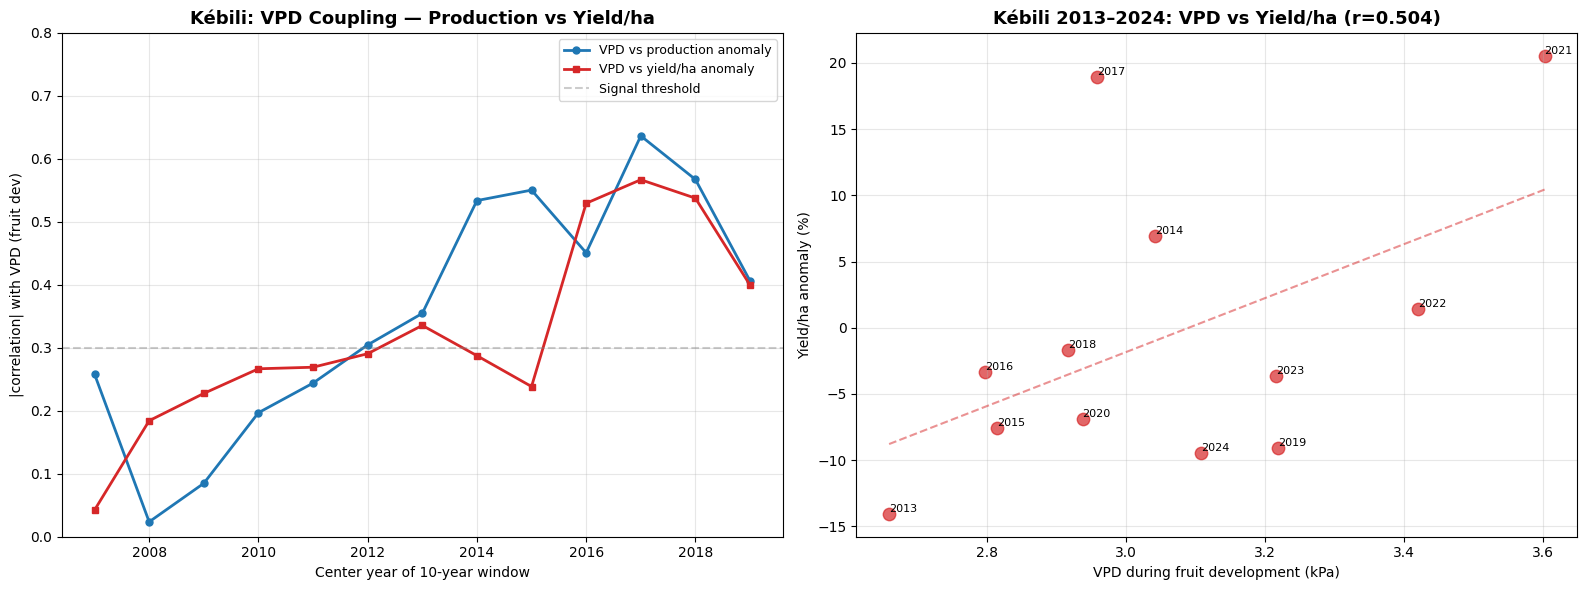


VERDICT

  Kébili VPD re-coupling (Δ|r| early→late):
    On production anomaly: +0.285
    On yield/ha anomaly:   +0.462

  ✅ THE SIGNAL SURVIVES AREA NORMALIZATION.

  The VPD-yield coupling increase in Kébili is NOT a spatial
  composition artifact. Even after removing the effect of area
  expansion, productivity per hectare is becoming more sensitive
  to atmospheric water demand. This is consistent with the
  aquifer degradation hypothesis: as groundwater supply becomes
  constrained, years with high VPD (high evaporative demand)
  can no longer be fully compensated by irrigation.

  Rolling slope on yield/ha: +0.0329/yr
  This strengthens the paper's central claim.

✓ Saved critical test results and enriched dataset


In [37]:
# ============================================================
# Cell 30: VPD decoupling test on YIELD PER HECTARE
# ============================================================
# THE CRITICAL TEST: Does Kébili's VPD re-coupling signal
# survive when we use yield/ha instead of raw production?
#
# If YES → the re-coupling is a real aquifer vulnerability signal
# If NO → it was a spatial composition artifact (new plantations
#          in exposed locations, not degradation of existing oases)

EARLY = (2002, 2012)
LATE = (2013, 2024)

vpd_col = 'VPD_kPa_fruit_dev_mean'

print(f"{'='*70}")
print(f"CRITICAL TEST: VPD-YIELD DECOUPLING ON YIELD PER HECTARE")
print(f"{'='*70}")

# --- Two-period test on yield/ha anomaly ---
print(f"\nTwo-period comparison ({EARLY[0]}-{EARLY[1]} vs {LATE[0]}-{LATE[1]}):")
print(f"\n{'Gov':<10} {'Target':<20} {'r(early)':>10} {'r(late)':>10} {'Δ|r|':>10} {'Signal':>14}")
print("-" * 75)

critical_results = []
for gov in ['Tozeur', 'Kebili', 'Gafsa', 'Gabes']:
    sub_early = annual_with_yield[
        (annual_with_yield['governorate'] == gov) &
        (annual_with_yield['year'] >= EARLY[0]) &
        (annual_with_yield['year'] <= EARLY[1])
    ]
    sub_late = annual_with_yield[
        (annual_with_yield['governorate'] == gov) &
        (annual_with_yield['year'] >= LATE[0]) &
        (annual_with_yield['year'] <= LATE[1])
    ]

    for target, target_col in [('production anomaly', 'production_anomaly_pct'),
                                ('yield/ha anomaly', 'yield_anomaly_pct')]:
        r_early = sub_early[vpd_col].corr(sub_early[target_col])
        r_late = sub_late[vpd_col].corr(sub_late[target_col])
        delta = abs(r_late) - abs(r_early)

        if delta > 0.10:
            signal = "↑ RE-COUPLING"
        elif delta < -0.10:
            signal = "↓ DECOUPLING"
        else:
            signal = "→ STABLE"

        marker = " **" if abs(delta) > 0.20 else ""
        print(f"  {gov:<8} {target:<18} {r_early:>+10.3f} {r_late:>+10.3f} {delta:>+10.3f} {signal}{marker}")

        critical_results.append({
            'governorate': gov, 'target': target,
            'r_early': r_early, 'r_late': r_late,
            'delta_abs_r': delta
        })

    print()  # blank line between governorates

# --- Rolling window on yield/ha for Kébili ---
print(f"\n{'='*70}")
print(f"KÉBILI ROLLING VPD-YIELD/HA COUPLING (10-year window)")
print(f"{'='*70}")

kebili_data = annual_with_yield[annual_with_yield['governorate'] == 'Kebili'].sort_values('year')
window = 10

rolling_comparison = []
for cy in range(kebili_data['year'].min() + window//2,
                 kebili_data['year'].max() - window//2 + 1):
    w = kebili_data[(kebili_data['year'] >= cy - window//2) &
                     (kebili_data['year'] <= cy + window//2)]

    r_prod = w[vpd_col].corr(w['production_anomaly_pct'])
    r_yield = w[vpd_col].corr(w['yield_anomaly_pct'])

    rolling_comparison.append({
        'center_year': cy,
        'r_vpd_production': abs(r_prod),
        'r_vpd_yield_ha': abs(r_yield)
    })

rc_df = pd.DataFrame(rolling_comparison)

print(f"\n{'Year':>6} {'|r| with prod anom':>20} {'|r| with yield/ha anom':>22} {'Δ':>8}")
print("-" * 60)
for _, row in rc_df.iterrows():
    diff = row['r_vpd_yield_ha'] - row['r_vpd_production']
    print(f"  {int(row['center_year'])} {row['r_vpd_production']:>20.3f} {row['r_vpd_yield_ha']:>22.3f} {diff:>+8.3f}")

# Slopes
slope_prod = np.polyfit(rc_df['center_year'], rc_df['r_vpd_production'], 1)[0]
slope_yield = np.polyfit(rc_df['center_year'], rc_df['r_vpd_yield_ha'], 1)[0]

print(f"\n  Trend slope (production anomaly): {slope_prod:+.4f}/yr")
print(f"  Trend slope (yield/ha anomaly):   {slope_yield:+.4f}/yr")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: rolling comparison
ax1 = axes[0]
ax1.plot(rc_df['center_year'], rc_df['r_vpd_production'], 'o-',
         color='tab:blue', linewidth=2, markersize=5, label='VPD vs production anomaly')
ax1.plot(rc_df['center_year'], rc_df['r_vpd_yield_ha'], 's-',
         color='tab:red', linewidth=2, markersize=5, label='VPD vs yield/ha anomaly')
ax1.axhline(y=0.3, color='gray', linestyle='--', alpha=0.4, label='Signal threshold')
ax1.set_xlabel('Center year of 10-year window')
ax1.set_ylabel('|correlation| with VPD (fruit dev)')
ax1.set_title('Kébili: VPD Coupling — Production vs Yield/ha', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.8)

# Right: scatter for late period
ax2 = axes[1]
keb_late = annual_with_yield[
    (annual_with_yield['governorate'] == 'Kebili') &
    (annual_with_yield['year'] >= 2013)
]
ax2.scatter(keb_late[vpd_col], keb_late['yield_anomaly_pct'],
            s=80, color='tab:red', alpha=0.7)
for _, row in keb_late.iterrows():
    ax2.annotate(f"{int(row['year'])}", (row[vpd_col], row['yield_anomaly_pct']),
                 fontsize=8, ha='left', va='bottom')

# Trend line
z = np.polyfit(keb_late[vpd_col].values, keb_late['yield_anomaly_pct'].values, 1)
x_line = np.linspace(keb_late[vpd_col].min(), keb_late[vpd_col].max(), 50)
ax2.plot(x_line, np.polyval(z, x_line), '--', color='tab:red', alpha=0.5)

r_val = keb_late[vpd_col].corr(keb_late['yield_anomaly_pct'])
ax2.set_xlabel('VPD during fruit development (kPa)')
ax2.set_ylabel('Yield/ha anomaly (%)')
ax2.set_title(f'Kébili 2013–2024: VPD vs Yield/ha (r={r_val:.3f})', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DOCS}/vpd_yield_ha_critical_test.png', dpi=150, bbox_inches='tight')
plt.show()

# --- VERDICT ---
crit_df = pd.DataFrame(critical_results)
keb_prod = crit_df[(crit_df['governorate']=='Kebili') & (crit_df['target']=='production anomaly')]
keb_yield = crit_df[(crit_df['governorate']=='Kebili') & (crit_df['target']=='yield/ha anomaly')]

prod_delta = keb_prod['delta_abs_r'].values[0]
yield_delta = keb_yield['delta_abs_r'].values[0]

print(f"\n{'='*70}")
print(f"VERDICT")
print(f"{'='*70}")
print(f"\n  Kébili VPD re-coupling (Δ|r| early→late):")
print(f"    On production anomaly: {prod_delta:+.3f}")
print(f"    On yield/ha anomaly:   {yield_delta:+.3f}")

if yield_delta > 0.10:
    print(f"""
  ✅ THE SIGNAL SURVIVES AREA NORMALIZATION.

  The VPD-yield coupling increase in Kébili is NOT a spatial
  composition artifact. Even after removing the effect of area
  expansion, productivity per hectare is becoming more sensitive
  to atmospheric water demand. This is consistent with the
  aquifer degradation hypothesis: as groundwater supply becomes
  constrained, years with high VPD (high evaporative demand)
  can no longer be fully compensated by irrigation.

  Rolling slope on yield/ha: {slope_yield:+.4f}/yr
  This strengthens the paper's central claim.
""")
elif yield_delta > -0.05:
    print(f"""
  ~ INCONCLUSIVE.

  The re-coupling signal is weaker on yield/ha ({yield_delta:+.3f})
  than on raw production ({prod_delta:+.3f}). Area expansion partially
  explains the original signal, but a residual effect remains.
  The paper should report both numbers and discuss the ambiguity.
""")
else:
    print(f"""
  ❌ THE SIGNAL DISAPPEARS AFTER AREA NORMALIZATION.

  The apparent VPD re-coupling was a spatial composition artifact:
  new plantations in more climate-exposed locations drove the signal,
  not aquifer degradation affecting existing oases. The paper must
  be reframed — the Kébili vulnerability story weakens, but the
  GRACE depletion and forecasting failure findings remain valid.
""")

# Save
crit_df.to_csv(f'{DOCS}/vpd_yield_ha_critical_test.csv', index=False)
area_production.to_csv(os.path.join(AREA_DIR, 'production_with_area.csv'), index=False)
annual_with_yield.to_csv(f'{COMPILED}/annual_enriched_with_yield_ha.csv', index=False)
print(f"✓ Saved critical test results and enriched dataset")